In [1]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 24.9 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from wordcloud import WordCloud
import re
import json
from konlpy.tag import Okt
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from nltk import ngrams
from itertools import chain


# 데이터 로드

In [ ]:
# 파일 경로
# 원하는 파일 경로 지정
path = '/content/'

styler_ai = pd.read_csv(path + '의류관리기_AI모델.csv')
styler_gen = pd.read_csv(path + '의류관리기_일반모델.csv')
styler_vs = pd.read_csv(path + '의류관리기_비교글.csv')

vacuum_ai = pd.read_csv(path + '무선스틱청소기_AI모델.csv')
vacuum_gen = pd.read_csv(path + '무선스틱청소기_일반모델.csv')
vacuum_vs = pd.read_csv(path + '무선스틱청소기_비교글.csv')

robot_gen = pd.read_csv(path + '로봇청소기_AI&일반모델.csv')

In [ ]:
# 각 데이터 content 평균 길이
print("Styler AI 평균 길이:", np.mean(styler_ai['content'].astype(str).apply(len)))
print("Styler Gen 평균 길이:", np.mean(styler_gen['content'].astype(str).apply(len)))
print("Styler VS 평균 길이:", np.mean(styler_vs['content'].astype(str).apply(len)))

print("Vacuum AI 평균 길이:", np.mean(vacuum_ai['content'].astype(str).apply(len)))
print("Vacuum Gen 평균 길이:", np.mean(vacuum_gen['content'].astype(str).apply(len)))
print("Vacuum VS 평균 길이:", np.mean(vacuum_vs['content'].astype(str).apply(len)))

print("Robot Gen 평균 길이:", np.mean(robot_gen['content'].astype(str).apply(len)))

In [ ]:
styler_ai.head()

,title,content,date,link,platform
0,LG 화면 구부러지는 TV로 게임한다 LG전자 강남에 금성오락실 열어 외 34건 O...,LG 디스클로저 K뉴스헤드라인 K헤드라인 knews 한국외신뉴스 한국상장회사 화면 ...,2022-10-13,https://blog.naver.com/disclosurekorea/2228989...,blog
1,대용량 건조기의 리더 삼성 디지털프라자 BESPOKE 그랑데 건조기 AI 20kg ...,BESPOKE 그랑데 건조기 AI 20kg20kg 대용량 건조기의 리더 안녕하세요 ...,2022-01-14,https://blog.naver.com/crystaltour/222621692431,blog
2,HAPPY 나답게 YEAR 공유이벤트 나의옷장으로,2022년은 나답게 보내볼까요 할머니의옷장에서 나의옷장으로 요즘은 빈티지가 유행이지...,2022-01-14,https://blog.naver.com/meeya00/222621676988,blog
3,삼성 그랑데AI 드럼 건조기세탁기 추천 삼성 디지털프라자 방문기,드럼 세탁기 건조기 제품을 찾을 때 과거에는 용량이 크지 않는 제품을 선호하기도 했...,2022-12-30,https://blog.naver.com/gyoil/222970521388,blog
4,평촌골프 최고의 시설에서 골프 레슨 받고 싱글 플레이어 도전,안녕하세요 4계절 중 골프치기 가장 좋은 계절이 왔습니다 8월 말부터 필드에는 시원...,2022-09-02,https://blog.naver.com/fitin_golf/222865120695,blog


## 추가 전처리

In [ ]:
# 불용어 목록
irrelevant_title = [
    '분양','오피스텔','분양안내','분양정보','부동산','분양소식','모델하우스','아파트','힐스테이트',
    '평촌골프', '골프연습장', '레슨', '골프', '안양골프장', '피트인골프존'
]

irrelevant_content = [
    '테크컨퍼런스', '분양','오피스텔','분양안내','분양정보','부동산','분양소식','모델하우스','중고차','힐스테이트',
    '평촌골프', '골프연습장', '레슨', '골프', '안양골프장', '피트인골프존'
]

def remove_irrelevant(data, title_keywords, content_keywords):
    # 제목의 불용어 패턴 생성
    title_pattern = '|'.join(title_keywords)
    # 내용의 불용어 패턴 생성
    content_pattern = '|'.join(content_keywords)

    # 제목 또는 내용에서 불용어가 포함된 행 제거
    filtered_data = data[
        ~data['title'].str.contains(title_pattern, case=False, na=False) &
        ~data['content'].str.contains(content_pattern, case=False, na=False)
    ]

    return filtered_data

In [ ]:
# 파일 경로
# 원하는 파일 경로 지정
path = '/content/'

styler_ai = remove_irrelevant(styler_ai, irrelevant_title, irrelevant_content)
styler_gen = remove_irrelevant(styler_gen, irrelevant_title, irrelevant_content)
styler_vs = remove_irrelevant(styler_vs, irrelevant_title, irrelevant_content)

vacuum_ai = remove_irrelevant(vacuum_ai, irrelevant_title, irrelevant_content)
vacuum_gen = remove_irrelevant(vacuum_gen, irrelevant_title, irrelevant_content)
vacuum_vs = remove_irrelevant(vacuum_vs, irrelevant_title, irrelevant_content)

robot_gen = remove_irrelevant(robot_gen, irrelevant_title, irrelevant_content)

## 연도별

_2022: 2020 ~ 2022

_2023: 2023

_2024: 2024

In [ ]:
# 데이터를 연도별로 분리하여 새로운 DataFrame 생성
def split_by_year(data, name):
    data['year'] = data['date'].astype(str).str[:4]  # 연도 추출
    year_conditions = {
        '2022': ['2020', '2021', '2022'],
        '2023': ['2023'],
        '2024': ['2024']
    }
    for year, valid_years in year_conditions.items():
        filtered_data = data[data['year'].isin(valid_years)].copy()
        globals()[f"{name}_{year}"] = filtered_data.drop(columns=['year'])

split_by_year(styler_ai, 'styler_ai')
split_by_year(styler_gen, 'styler_gen')
split_by_year(styler_vs, 'styler_vs')
split_by_year(vacuum_ai, 'vacuum_ai')
split_by_year(vacuum_gen, 'vacuum_gen')
split_by_year(vacuum_vs, 'vacuum_vs')
split_by_year(robot_gen, 'robot_gen')

In [ ]:
print(vacuum_gen_2022['date'].min())
print(vacuum_gen_2022['date'].max())

In [ ]:
seasons = ['spring', 'summer', 'fall', 'winter']
datasets = ['styler_ai', 'styler_gen', 'styler_vs', 'vacuum_ai', 'vacuum_gen', 'vacuum_vs', 'robot_gen']
years = ['2022', '2023', '2024']

for dataset in datasets:
    for year in years:
            df_name = f"{dataset}_{year}"
            print(f"{df_name} rows: {globals()[df_name].shape[0]}")


## 계절별

봄 (Spring): 3월, 4월, 5월 (3, 4, 5)

여름 (Summer): 6월, 7월, 8월 (6, 7, 8)

가을 (Autumn/Fall): 9월, 10월, 11월 (9, 10, 11)

겨울 (Winter): 12월, 1월, 2월 (12, 1, 2)

In [ ]:
# 데이터를 계절별로 분리하여 새로운 DataFrame 생성
def split_by_season(data, name):
    data['month'] = data['date'].astype(str).str[5:7].astype(int)  # 월 추출
    season_conditions = {
        'spring': [3, 4, 5],
        'summer': [6, 7, 8],
        'fall': [9, 10, 11],
        'winter': [12, 1, 2]
    }
    for season, months in season_conditions.items():
        filtered_data = data[data['month'].isin(months)].copy()
        globals()[f"{name}_{season}"] = filtered_data.drop(columns=['month'])

split_by_season(styler_ai, 'styler_ai')
split_by_season(styler_gen, 'styler_gen')
split_by_season(styler_vs, 'styler_vs')
split_by_season(vacuum_ai, 'vacuum_ai')
split_by_season(vacuum_gen, 'vacuum_gen')
split_by_season(vacuum_vs, 'vacuum_vs')
split_by_season(robot_gen, 'robot_gen')

In [ ]:
vacuum_gen_summer.head(4)

In [ ]:
seasons = ['spring', 'summer', 'fall', 'winter']
datasets = ['styler_ai', 'styler_gen', 'styler_vs', 'vacuum_ai', 'vacuum_gen', 'vacuum_vs', 'robot_gen']
years = ['2022', '2023', '2024']

for dataset in datasets:
        for season in seasons:
            df_name = f"{dataset}_{season}"
            print(f"{df_name} rows: {globals()[df_name].shape[0]}")


## 연도 + 계절별

데이터_모델_연도_계절

ex: vacuum_gen_2023_spring

In [ ]:
split_by_season(styler_ai_2022, 'styler_ai_2022')
split_by_season(styler_ai_2023, 'styler_ai_2023')
split_by_season(styler_ai_2024, 'styler_ai_2024')

split_by_season(styler_gen_2022, 'styler_gen_2022')
split_by_season(styler_gen_2023, 'styler_gen_2023')
split_by_season(styler_gen_2024, 'styler_gen_2024')

split_by_season(styler_vs_2022, 'styler_vs_2022')
split_by_season(styler_vs_2023, 'styler_vs_2023')
split_by_season(styler_vs_2024, 'styler_vs_2024')

split_by_season(vacuum_ai_2022, 'vacuum_ai_2022')
split_by_season(vacuum_ai_2023, 'vacuum_ai_2023')
split_by_season(vacuum_ai_2024, 'vacuum_ai_2024')

split_by_season(vacuum_gen_2022, 'vacuum_gen_2022')
split_by_season(vacuum_gen_2023, 'vacuum_gen_2023')
split_by_season(vacuum_gen_2024, 'vacuum_gen_2024')

split_by_season(vacuum_vs_2022, 'vacuum_vs_2022')
split_by_season(vacuum_vs_2023, 'vacuum_vs_2023')
split_by_season(vacuum_vs_2024, 'vacuum_vs_2024')

split_by_season(robot_gen_2022, 'robot_gen_2022')
split_by_season(robot_gen_2023, 'robot_gen_2023')
split_by_season(robot_gen_2024, 'robot_gen_2024')

In [ ]:
seasons = ['spring', 'summer', 'fall', 'winter']
datasets = ['styler_ai', 'styler_gen', 'styler_vs', 'vacuum_ai', 'vacuum_gen', 'vacuum_vs', 'robot_gen']
years = ['2022', '2023', '2024']

for dataset in datasets:
    for year in years:
        for season in seasons:
            df_name = f"{dataset}_{year}_{season}"
            print(f"{df_name} rows: {globals()[df_name].shape[0]}")


## 저장

### CSV

In [ ]:
import os

# CSV로 저장
def save_dataframes_as_csv(names, path):
    for name in names:
        df = globals().get(name)
        if df is not None:
            # 파일 경로에 path 추가
            file_path = os.path.join(path, f"{name}.csv")
            df.to_csv(file_path, index=False, encoding='utf-8-sig')  # 한글 저장을 위한 utf-8-sig 인코딩 사용

# 경로 설정
path = '/content/drive/MyDrive/LG/Data/split'

# 연도 및 계절별로 생성된 데이터 프레임 이름 리스트
year_season_dataframes = [
    # 전체
    'styler_ai', 'styler_gen', 'styler_vs',
    'vacuum_ai', 'vacuum_gen', 'vacuum_vs',
    'robot_gen',

    # 연도별
    'styler_ai_2022', 'styler_ai_2023', 'styler_ai_2024',
    'styler_gen_2022', 'styler_gen_2023', 'styler_gen_2024',
    'styler_vs_2022', 'styler_vs_2023', 'styler_vs_2024',
    'vacuum_ai_2022', 'vacuum_ai_2023', 'vacuum_ai_2024',
    'vacuum_gen_2022', 'vacuum_gen_2023', 'vacuum_gen_2024',
    'vacuum_vs_2022', 'vacuum_vs_2023', 'vacuum_vs_2024',
    'robot_gen_2022', 'robot_gen_2023', 'robot_gen_2024',

    # 계절별
    'styler_ai_spring', 'styler_ai_summer', 'styler_ai_fall', 'styler_ai_winter',
    'styler_gen_spring', 'styler_gen_summer', 'styler_gen_fall', 'styler_gen_winter',
    'styler_vs_spring', 'styler_vs_summer', 'styler_vs_fall', 'styler_vs_winter',
    'vacuum_ai_spring', 'vacuum_ai_summer', 'vacuum_ai_fall', 'vacuum_ai_winter',
    'vacuum_gen_spring', 'vacuum_gen_summer', 'vacuum_gen_fall', 'vacuum_gen_winter',
    'vacuum_vs_spring', 'vacuum_vs_summer', 'vacuum_vs_fall', 'vacuum_vs_winter',
    'robot_gen_spring', 'robot_gen_summer', 'robot_gen_fall', 'robot_gen_winter',

    # 연도 + 계절별
    'styler_ai_2022_spring', 'styler_ai_2022_summer', 'styler_ai_2022_fall', 'styler_ai_2022_winter',
    'styler_ai_2023_spring', 'styler_ai_2023_summer', 'styler_ai_2023_fall', 'styler_ai_2023_winter',
    'styler_ai_2024_spring', 'styler_ai_2024_summer', 'styler_ai_2024_fall', 'styler_ai_2024_winter',
    'styler_gen_2022_spring', 'styler_gen_2022_summer', 'styler_gen_2022_fall', 'styler_gen_2022_winter',
    'styler_gen_2023_spring', 'styler_gen_2023_summer', 'styler_gen_2023_fall', 'styler_gen_2023_winter',
    'styler_gen_2024_spring', 'styler_gen_2024_summer', 'styler_gen_2024_fall', 'styler_gen_2024_winter',
    'styler_vs_2022_spring', 'styler_vs_2022_summer', 'styler_vs_2022_fall', 'styler_vs_2022_winter',
    'styler_vs_2023_spring', 'styler_vs_2023_summer', 'styler_vs_2023_fall', 'styler_vs_2023_winter',
    'styler_vs_2024_spring', 'styler_vs_2024_summer', 'styler_vs_2024_fall', 'styler_vs_2024_winter',
    'vacuum_ai_2022_spring', 'vacuum_ai_2022_summer', 'vacuum_ai_2022_fall', 'vacuum_ai_2022_winter',
    'vacuum_ai_2023_spring', 'vacuum_ai_2023_summer', 'vacuum_ai_2023_fall', 'vacuum_ai_2023_winter',
    'vacuum_ai_2024_spring', 'vacuum_ai_2024_summer', 'vacuum_ai_2024_fall', 'vacuum_ai_2024_winter',
    'vacuum_gen_2022_spring', 'vacuum_gen_2022_summer', 'vacuum_gen_2022_fall', 'vacuum_gen_2022_winter',
    'vacuum_gen_2023_spring', 'vacuum_gen_2023_summer', 'vacuum_gen_2023_fall', 'vacuum_gen_2023_winter',
    'vacuum_gen_2024_spring', 'vacuum_gen_2024_summer', 'vacuum_gen_2024_fall', 'vacuum_gen_2024_winter',
    'vacuum_vs_2022_spring', 'vacuum_vs_2022_summer', 'vacuum_vs_2022_fall', 'vacuum_vs_2022_winter',
    'vacuum_vs_2023_spring', 'vacuum_vs_2023_summer', 'vacuum_vs_2023_fall', 'vacuum_vs_2023_winter',
    'vacuum_vs_2024_spring', 'vacuum_vs_2024_summer', 'vacuum_vs_2024_fall', 'vacuum_vs_2024_winter',
    'robot_gen_2022_spring', 'robot_gen_2022_summer', 'robot_gen_2022_fall', 'robot_gen_2022_winter',
    'robot_gen_2023_spring', 'robot_gen_2023_summer', 'robot_gen_2023_fall', 'robot_gen_2023_winter',
    'robot_gen_2024_spring', 'robot_gen_2024_summer', 'robot_gen_2024_fall', 'robot_gen_2024_winter'
]

# 데이터프레임을 CSV로 저장
save_dataframes_as_csv(year_season_dataframes, path)


### pickle

In [ ]:
import pickle
import os

# Pickle로 저장
def save_dataframes_as_pickle(names, path):
    for name in names:
        df = globals().get(name)
        if df is not None:
            # 파일 경로에 path 추가
            file_path = os.path.join(path, f"{name}.pkl")
            with open(file_path, 'wb') as file:
                pickle.dump(df, file)

# 경로 설정
path = '/content/drive/MyDrive/LG/Data/split'

# 데이터프레임을 Pickle로 저장
save_dataframes_as_pickle(year_season_dataframes, path)


# 전처리

## 토큰화 & 불용어 처리

* okt.morphs: okt 객체를 활용하여 형태소 단어로 나눔

    * 문장을 명사, 동사, 형용사, 조사 등과 같은 형태소 단위로 분리

### 불용어 처리 리스트

In [ ]:
stop_words = ['수', '있다', '을', '를', '이', '것', '같다', '으로', '와', '는', '은']

# 전처리 최종: 여기부터 분석 전까지 전처리 과정 최종

## 특정 단어 병합 후 n-gram 확인

* 노이즈 제거 (특정 단어 병합) 후 trigram, bigram에서 나온거를 붙여서 하나의 단어로 만들기

In [ ]:
import re

def preprocessing(review, okt, remove_stopwords=False, stop_words=[]):
    # 함수 인자 설명
    # review: 전처리할 텍스트
    # okt: okt 객체를 반복적으로 생성하지 않고 미리 생성 후 인자로 받음
    # remove_stopwords: 불용어를 제거할지 여부 선택. 기본값 False
    # stop_words: 불용어 사전은 사용자가 직접 입력, 기본값 빈 리스트

    # 1. URL 제거
    review = re.sub(r'http[s]?://\S+|www\.\S+', '', review)

    # 2. 한글 및 공백만 남기고, 자음/모음만 이루어진 한글 제거
    review_text = re.sub(r'[^가-힣\s]', '', review)  # 한글 및 공백 제외한 문자 제거
    review_text = re.sub(r'\b[ㄱ-ㅎㅏ-ㅣ]+\b', '', review_text)  # 자음/모음만 이루어진 단어 제거

    # 3. okt 객체를 활용하여 형태소 단위로 나눔
    word_review = okt.morphs(review_text, stem=True)

    # 4. 불용어 제거 (선택)
    if remove_stopwords:
        word_review = [token for token in word_review if token not in stop_words]

    return word_review


In [ ]:
# 특정 단어 병합 함수

def merge_tokens(tokens):
    """
    특정 단어 조합을 합치고 변환합니다.
    """
    # 1. 특정 단어 조합을 합치기 위한 사전 정의
    merge_rules = {
        ('그', '랑', '데'): '그랑데',
        ('랑','데'): '랑데',
        ('그', '랑데'): '그랑데',
        ('그랑', '데'): '그랑데',
        ('삼성', '에어', '드레서'): '삼성에어드레서',
        ('삼', '성비', '스포크'): '삼성비스포크',
        ('삼', '성'): '삼성',
        ('옷', '걸이'): '옷걸이',
        ('오브', '제', '컬렉션'): '오브제컬렉션',
        ('비', '스포크', '에어', '드레서'): '비스포크에어드레서',
        ('의류', '관리', '기'): '의류관리기',
        ('의류', '관리', '기르다'): '의류관리기',
        ('오다', '뉴', '스타', '이르다'): '올뉴스타일러',
        ('스타', '이르다'): '스타일러',
        ('스타', '일러'): '스타일러',
        ('스타일러', '컬렉션'): '스타일러컬렉션',
        ('비', '스포크'): '비스포크',
        ('에어', '드레서'): '에어드레서',
        ('삼성', '전자'): '삼성전자',
        ('대', '용량'): '대용량',
        ('오브제', '컬렉션'): '오브제컬렉션',
        ('스타', '이르다', '오브제', '컬렉션'): '스타일러오브제컬렉션',
        ('제', '습'): '제습',
        ('삼성', '비스포크에어드레서'): '삼성비스포크에어드레서',
        ('트롬','스타', '이르다'): '트롬스타일러',
        ('고압', '스티', '머'): '고압스티머',
        ('다이렉트','결혼','준비'): '다이렉트결혼준비',
        ('슈', '드레서'): '슈드레서',
        ('제트', '스팀'): '듀얼에어워시',
        ('너무', '좋다'): '너무좋다',
        ('체험', '단'): '체험단',
        ('스타', '일링'): '스타일링',
        ('전자', '서비스', '센터'): '전자서비스센터',
        ('사용', '되다'): '사용되다',
        ('트롬스타' '이르다'): '트롬스타일러',
        ('무빙행', '어'): '다이내믹무빙행어',
        ('가성', '비'): '가성비',
        ('실시간', '설정'): '실시간설정',
        ('뉴', '스타일러'): '뉴스타일러',
        ('스타일러', '컬렉션'): '스타일러컬렉션',
        ('드레스' ,'룸'): '드레스룸',
        ('올인원',  '타워'): '올인원타워',
        ('의류','관리'): '의류관리',
        ('의류관리','기'): '의류관리기',
        ('건조기', '시트'): '건조기시트',


        ('삼성', '비스포크에어드레서'): '삼성비스포크에어드레서',
        ('스타일러', '컬렉션'): '스타일러컬렉션',
        ('에어', '워시'): '에어워시',
        ('건조', '코스'): '건조코스',
        ('의', '류관', '리기'): '의류관리기',
        ('코드', '제로'): '코드제로',
        ('코드제로', '무선', '청소기'): '코드제로무선청소기',
        ('무선', '청소기'): '무선청소기',
        ('코드제로', '무선청소기'): '코드제로무선청소기',
        ('코드', '제로', '컬렉션'): '코드제로컬렉션',
        ('일렉트로', '룩스'): '일렉트로룩스',
        ('흡입', '력'): '흡입력',
        ('거치', '대'): '거치대',
        ('룩스', '무선', '청소기'): '룩스무선청소기',
        ('일렉트로', '룩스', '퓨어'): '일렉트로룩스퓨어',
        ('일렉트로', '룩스퓨어'): '일렉트로룩스퓨어',
        ('무선', '청소기'): '무선청소기',
        ('룩스', '무선청소기'): '룩스무선청소기',

        ('무선', '청소기'): '무선청소기',
        ('코드', '제로'): '코드제로',
        ('스팀', '물걸레'): '스팀물걸레',
        ('먼지', '통'): '먼지통',
        ('흡입', '구'): '흡입구',
        ('흡', '입구'): '흡입구',
        ('흡입', '구가'): '흡입구',
        ('흡입', '구르다'): '흡입구',
        ('비', '스포크', '제트'): '비스포크제트',
        ('코드', '제로', '오브', '제', '컬렉션'): '코드제로오브제컬렉션',
        ('청정', '스테이션'): '청정스테이션',
        ('안심', '스팀', '물걸레'): '안심스팀물걸레',
        ('안심', '스팀', '모드'): '안심스팀모드',
        ('에르', '고', '라피도'): '에르고라피도',
        ('구', '성품'): '구성품',
        ('물', '세척'): '물세척',
        ('유선', '청소기'): '유선청소기',
        ('먼지', '봉투'): '먼지봉투',
        ('레몬', '테라스', '카페'): '레몬테라스카페',


        # 의류관리기 AI
        # LG
        ('고압', '스티머'): '고압스티머',
        ('스팀', '다리미'): '스팀다리미',
        ('빌', '트인'): '빌트인',
        ('빌트', '인'): '빌트인',
        ('빌트인', '고압스티머', '스팀다리미'): '빌트인고압스티머',
        ('무빙행어'): '다이내믹무빙행어',
        ('자동환기'): '자동환기시스템',
        ('자동', '환기'): '자동환기시스템',
        ('듀얼히팅트루스팀', '듀얼트루스팀', '트루스팀'): '듀얼히팅트루스팀',
        ('표준', '코스',): '29분표준코스',
        ('표준코스',): '29분표준코스',
        ('인공', '지능'): '인공지능',
        ('인공지능', '건조'): '인공지능건조',
        ('인공지능', '스타일링'): '인공지능스타일링',


        # 삼성
        ('섬세', '건조'): 'AI섬세건조',
        ('절약', '모드'): 'AI절약모드',
        ('코스', '추천'): 'AI코스추천',
        ('듀얼', '제트', '스팀'): '듀얼에어워시',
        ('듀얼', '에어', '워시'): '듀얼에어워시',
        ('듀얼', '에어'): '듀얼에어워시',
        ('대용량', '케어', '코스'): '대용량케어코스',
        ('대용량', '케어'): '대용량케어코스',
        ('집진', '케어'): '트리플집진케어',

        ('물샘', '방지',): '물샘방지',
        ('방지', '안심설계'): '물샘방지',
        ('안심', '설계'): '물샘방지',
        ('멀티', '행어'): '멀티행어',
        ('긴', '옷케어'): '긴옷케어',
        ('긴', '옷'): '긴옷케어',
        ('긴', '옷', '케어'): '긴옷케어',
        ('공간', '제습'): '공간제습',

        # 무선청소기 AI
        # LG
        ('오토', '스탑'): '오토스탑앤고',
        ('스탑', '앤고'): '오토스탑앤고',
        ('물', '걸레', '흡입'): '안심스팀물걸레흡입구',
        ('물걸레', '흡입구'): '안심스팀물걸레흡입구',
        ('안심', '스팀'): '안심스팀물걸레흡입구',
        ('안심', '스팀', '물걸레'): '안심스팀물걸레흡입구',
        ('스팀', '물걸레', '흡입'): '안심스팀물걸레흡입구',
        ('안심스팀물걸레흡입구'): '안심스팀물걸레흡입구',
        ('올인원타워 4.0'): '올인원타워 4.0',
        ('올인원타워',  '4.0'): '올인원타워 4.0',
        ('320W'): '320W 흡입력',
        ('320', 'W'): '320W 흡입력',

        # 삼성
        ('AI', '모드'): 'AI모드',
        ('고온', '세척', '브러시'): '고온세척브러시',
        ('세척', '브러시'): '고온세척브러시',
        ('물', '걸레'): '물걸레',
        ('고온', '세척', '물걸레'): '고온세척브러시',
        ('고온', '세척', '물'): '고온세척브러시',
        ('세척', '물걸레'): '고온세척브러시',
        ('세척', '물'): '고온세척브러시',
        ('청정', '스테이션'): '청정스테이션',
        ('310W'): '310W 흡입력',
        ('310', 'W'): '310W 흡입력',

        # 다이슨
        ('흡입', '력'): '흡입력',
        ('자동', '흡입', '력'): '자동흡입력조절',
        ('자동', '흡입력'): '자동흡입력조절',
        ('엉킴', '방지'): '엉킴방지',
        ('240', 'AW'): '240AW 흡입력',
        ('240', 'W'): '240AW 흡입력',
        ('일', '루미'): '일루미네이션',
        ('일루', '미네이션'): '일루미네이션',
        ('사용', '시간', '알림'): '사용시간알림',
        ('시간', '알림'): '사용시간알림',
        ('사용', '시간'): '사용시간알림',
        ('유지', '보수'): '유지보수알림',
        ('유지보수'): '유지보수알림',
        ('유지' ,'보수', '알림'): '유지보수알림',
        ('필터', '레이션'): '필터레이션',




        # 쓸모없는거
        ('전체', '화면'): '전체화면',
        ('자막', '안함'): '자막안함',
        ('자막', '안함', '옵션'): '자막안함옵션',
        ('글자', '크기'): '글자크기',
        ('크기','배경','색'): '크기배경색',
        ('배경','색','기본'): '배경색기본',
        ('골프', '연습장'): '골프연습장',
        ('회원', '님'): '회원님',
        ('골프', '레슨'): '골프레슨',
        ('도움말', '상태'): '도움말상태',
        ('문제' ,'발생'): '문제발생',
        ('가능하다', '영상'): '가능한영상',
        ('범례', '부동산', '거리'): '범례부동산거리',



        ('우리', '집'): '우리집',
        ('트루', '스팀'): '듀얼히팅트루스팀',
        ('기본', '옵션'): '기본옵션',
        ('방문', '설치'): '방문설치',
        ('시티', '파이'): '시티파이',
        ('다시', '시도'): '다시시도',
        ('기본', '자동', '옵션'): '기본자동옵션',
        ('자동', '기본', '자동'): '기본자동옵션',
        ('재무', '뉴스'): '재무뉴스',
        ('키', '워드'): '키워드',
        ('차량', '용'): '차량용',
        ('차이', '슨'): '다이슨',
        ('차이', '슨', '청소기'): '다이슨청소기',
        ('다이슨', '청소기'): '다이슨청소기',
        ('휴대', '용'): '휴대용',
        ('휴대', '용', '청소기'): '휴대용청소기',
        ('휴대용', '청소기'): '휴대용청소기',
        ('핸디', '형', '청소기'): '휴대용청소기',
        ('핸디', '형'): '휴대용',
        ('긴', '옷'): '긴옷',
        ('긴', '옷', '케어'): '긴옷케어',
        ('준비', '물'): '준비물',
        ('옷', '감'): '옷감',
        ('옷', '장'): '옷장',

        ('오브제', '컬렉션'): '오브제컬렉션', #추가
        ('로라','스타'): '로라스타', #추가
        ('바니','에르'): '바니에르', #추가
        ('시티','파이'): '시티파이', #추가
        ('스타일','에어'): '스타일에어', #추가
        ('스타일','랩'): '스타일랩', #추가
        ('차량','용'): '차량용', #추가
        ('트루','스팀'): '트루스팀', #추가
        ('류관','리기'): '의류관리기', #추가
        ('파이','스타일'): '시티파이 스타일랩', #추가
        ('시티','파이','스타일'): '시티파이 스타일랩', #추가
        ('미니','류관','리기'): '미니의류관리기', #추가
        ('옷장','냄새','제거'): '옷장냄새제거', #추가
        ('블랙','틴트','미러'): '블랙틴트미러', #추가
        ('파이','스타일','랩'): '시티파이 스타일랩', #추가
        ('에어','코트','너'): '에어코트너', #추가
        ('에코','퓨어','코리아'): '에코퓨어코리아', #추가
        ('라비','킷','에어'): '라비킷에어코트너', #추가
        ('LG', '전자'): 'LG전자', #추가


        ('옷', '방'): '옷방', #추가
        ('옷', '관리'): '옷관리', #추가
        ('새', '옷'): '새옷' #추가



    }

    # 2. Tokens를 N-gram으로 변환 후 단어 병합
    merged_tokens = []
    i = 0
    while i < len(tokens):
        matched = False
        for n in range(4, 1, -1):  # 4-gram부터 2-gram까지 검사
            if tuple(tokens[i:i+n]) in merge_rules:
                merged_tokens.append(merge_rules[tuple(tokens[i:i+n])])
                i += n
                matched = True
                break
        if not matched:
            merged_tokens.append(tokens[i])
            i += 1

    return merged_tokens

### 불용어 처리 리스트 (최종)

In [ ]:
### 불용어 처리 리스트
#stop_words = ['수', '있다', '을', '를', '이', '것', '같다', '으로', '와', '는', '은', '하다', '때문', '에', '적', '인',
#              '분', '들', '때', '가', '로', '의', '이다', '니다', '니', '뿐', '만', '아니다', '다이렉트결혼준비',
#              '매', '일', '매일', '도', '해', '요', '체험단', '전자서비스센터', '까지', '저', '한', '에는', '과',
#              '에서', '제', '다', '후', '나', '저', '사용', '되다', '사용되다'
#              ]

In [ ]:
### 불용어 처리 리스트
stop_words = {'이다', '에서', '후', '번', '일', '랑', '보다', '를', '와', '내', '과', '되다', '전자서비스센터',
              '시', '때', '사용', '데', '을', '는', '매일', '가', '이', '개', '때문', '꼭', '경우', '은', '에도',
              '되어다', '수', '의', '없다', '나', '까지', '이제', '사용되다', '같다', '뿐', '해주다', '않다',
              '다이렉트결혼준비', '에', '전', '들', '중', '다', '기', '그렇다', '니', '도', '등', '있다',
              '분', '더', '정말', '습', '게', '하다', '적', '아니다', '매', '더욱', '슈', '인', '안', '해', 'S',
              '만', '바로', '로', '한', 'CB', '처럼', '니다', '그', '오브', '그리고', '통해', '점', '제', '이나',
              '한번', '글', '체험단', '요', '으로', '저희', '거', '하고', '것', '부터', '에는', '기다', '저',
              '블랙틴트미러', '그래서', '특히', '예요', '또한', '많이', '없이', '호텔', '수업', '교시', '출판',
              '서점', '이벤트', '발매', '돼다', '보시', '이라', '참고', '오다', '맞다', '같이', '근데', '그냥', '약간',
              '다음', '여기', '조금', '수가', '하나', '대해', '어떻다', '싶다', '이라고', '너무', '정도', '자주', '이렇게',
              '인데', '이기', '가장', '하지만', '해당', '한다는', '항상', '사하', '가장', '는걸', '아주', '고', '\n', '\xa0',
              ' ', '레몬테라스카페', '즉', '다음', '동영상', '취소', '재생', '속도', '음소거', '음소거설정', '실시간', '설정',
              '실시간설정', '다시시도'
              '골프', '레슨', '도움말', '도움말상태', '라이센스', '고화질', '영상', '해상도', '문제', '발생',
              '해상도', '자막', '안함', '초', '광고', '공유', '전체화면', '자막안함옵션',
              '글자', '크기배경색', '도움말', '상태', '배경색기본', '골프연습장', '회원님',
              '골프레슨', '죄송하다', '문제발생', '가능한영상', '자막안함', '글자크기',
              '범례부동산거리', '전체화면', '크기배경색','옵션', '기본자동옵션', '시가총액', '억원', '상승',
              '차량용', '차량', '용', '원', '현재', '동시', '군', '구시', '거리', '읍', '면', '도국', '지도',
              '범례', '부동산', '거리', '데이터', '다시시도', '존', '인', '피트', '회원님', '들다', '기본옵션', '오후', '우리집',
              '년', '집', '및', '준비물', '다시', '시도', '로켓', '배송'
              }




In [ ]:
from __future__ import annotations

from typing import Dict, List, Tuple, Optional, Iterable
from collections import Counter
from nltk.util import ngrams

# NOTE
# - 데이터 로드 / 불용어 리스트 / merge_tokens 함수 / stop_words 변수는 위 셀을 그대로 사용한다는 전제.
# - 아래부터는 "반복 토큰화/반복 변수 생성"을 줄이기 위한 파이프라인 코드.

def tokenize_text(
    text: str,
    okt,
    stop_words: Iterable[str],
    apply_merge: bool = True,
) -> List[str]:
    """텍스트 1건 -> 토큰 리스트"""
    if not isinstance(text, str):
        return []
    tokens = preprocessing(text, okt, remove_stopwords=True, stop_words=stop_words)
    if apply_merge:
        tokens = merge_tokens(tokens)
    return tokens

def tokenize_series(
    series,
    okt,
    stop_words: Iterable[str],
    apply_merge: bool = True,
) -> List[List[str]]:
    """시리즈(리뷰 컬럼) -> 토큰화 결과(list of tokens)"""
    return [tokenize_text(x, okt, stop_words, apply_merge=apply_merge) for x in series]

def get_year_bucket(date_str: str) -> Optional[str]:
    """'2020~2022'를 '2022'로 묶고, 2023/2024는 그대로."""
    if not isinstance(date_str, str):
        date_str = str(date_str)
    y = date_str[:4]
    if y in ("2020", "2021", "2022"):
        return "2022"
    if y in ("2023", "2024"):
        return y
    return None

def get_season(month: int) -> str:
    # 봄: 3-5, 여름: 6-8, 가을: 9-11, 겨울: 12-2
    if month in (3,4,5):
        return "spring"
    if month in (6,7,8):
        return "summer"
    if month in (9,10,11):
        return "fall"
    return "winter"

def build_views(
    df: pd.DataFrame,
    date_col: str = "date",
) -> Dict[Tuple[Optional[str], Optional[str]], pd.DataFrame]:
    """(year_bucket, season) 별 DataFrame view를 만든다.
    - key: (year_bucket or None, season or None)
    - (None, None): 전체
    - ('2024', None): 2024 전체
    - (None, 'spring'): 전체 중 봄
    - ('2024','spring'): 2024 중 봄
    """
    tmp = df.copy()
    tmp[date_col] = tmp[date_col].astype(str)
    tmp["_year_bucket"] = tmp[date_col].apply(get_year_bucket)

    # month 파싱: YYYYMMDD / YYYY-MM-DD 등 혼재 가능성을 감안
    def _parse_month(s: str) -> Optional[int]:
        s = str(s)
        m = re.search(r"(\d{4})[-/]?(\d{2})", s)
        if not m:
            return None
        return int(m.group(2))

    tmp["_month"] = tmp[date_col].apply(_parse_month)
    tmp["_season"] = tmp["_month"].apply(lambda x: get_season(x) if isinstance(x, int) else None)

    views: Dict[Tuple[Optional[str], Optional[str]], pd.DataFrame] = {}
    views[(None, None)] = tmp

    for y in ["2022","2023","2024"]:
        views[(y, None)] = tmp[tmp["_year_bucket"] == y]

    for s in ["spring","summer","fall","winter"]:
        views[(None, s)] = tmp[tmp["_season"] == s]

    for y in ["2022","2023","2024"]:
        for s in ["spring","summer","fall","winter"]:
            views[(y, s)] = tmp[(tmp["_year_bucket"] == y) & (tmp["_season"] == s)]

    return views

def ngram_counter(tokenized_docs: List[List[str]], n: int = 2) -> Counter:
    return Counter([g for toks in tokenized_docs for g in ngrams(toks, n)])

def top_k(counter: Counter, k: int = 30) -> List[Tuple[Tuple[str, ...], int]]:
    return counter.most_common(k)

def flatten_ngrams(ngram_items: List[Tuple[Tuple[str, ...], int]]) -> List[str]:
    """(ngram, count) -> ['a b', 'c d', ...]"""
    return [" ".join(g) for g,_ in ngram_items]


# Backward-compatible alias (기존 코드 재사용용)
def generate_ngrams(content: List[List[str]], n: int = 2) -> Counter:
    return ngram_counter(content, n=n)


In [ ]:
from konlpy.tag import Okt

# 1) 분석 대상 데이터셋 등록 (필요 시 여기만 수정)
DATASETS = {
    "styler_ai": styler_ai,
    "styler_gen": styler_gen,
    "styler_vs": styler_vs,
    "vacuum_ai": vacuum_ai,
    "vacuum_gen": vacuum_gen,
    "vacuum_vs": vacuum_vs,
    "robot_gen": robot_gen,
}

TEXT_COL = "content"
DATE_COL = "date"

okt = Okt()

# 2) year/season view 생성
VIEWS = {name: build_views(df, date_col=DATE_COL) for name, df in DATASETS.items()}

# 3) 토큰화 결과 캐싱: TOKENS[dataset][(year, season)] = List[List[str]]
TOKENS = {}
for name, views in VIEWS.items():
    TOKENS[name] = {}
    for key, vdf in views.items():
        TOKENS[name][key] = tokenize_series(vdf[TEXT_COL], okt, stop_words, apply_merge=True)

def get_tokens(dataset: str, year: str | None = None, season: str | None = None) -> List[List[str]]:
    return TOKENS[dataset][(year, season)]

# 예시) 2024년 봄, styler_ai 토큰화 결과 1건
get_tokens("styler_ai", "2024", "spring")[:1]


In [ ]:
# (선택) 기존 변수명 호환: 아래 셀들에서 *_content 변수를 그대로 쓰고 싶다면 활성화
# - 이후 코드에서 'styler_ai_2024_content' 같은 변수가 등장하므로, 한번에 생성해준다.

def _set_legacy_content_vars():
    # 전체
    for ds in DATASETS.keys():
        globals()[f"{ds}_content"] = get_tokens(ds, None, None)

    # year
    for ds in DATASETS.keys():
        for y in ["2022","2023","2024"]:
            globals()[f"{ds}_{y}_content"] = get_tokens(ds, y, None)

    # season
    for ds in DATASETS.keys():
        for s in ["spring","summer","fall","winter"]:
            globals()[f"{ds}_{s}_content"] = get_tokens(ds, None, s)

    # year + season
    for ds in DATASETS.keys():
        for y in ["2022","2023","2024"]:
            for s in ["spring","summer","fall","winter"]:
                globals()[f"{ds}_{y}_{s}_content"] = get_tokens(ds, y, s)

_set_legacy_content_vars()

# 확인
styler_ai_2024_spring_content[:1]


## 2.1 VOC → 구매 여정(Funnel) 연결 정리 / 2.2 전환 저해 vs 촉진 VOC

- 아래 셀은 **TOKENS 파이프라인**을 그대로 사용한다.
- 퍼널 키워드 사전(FUNNEL_DICT)과 전환 저해/촉진 사전(CONV_DICT)은 프로젝트에 맞게 **단어만 보강**하면 된다.
- 기본값은 가전 리뷰(VOC)에서 자주 등장하는 표현을 중심으로 최소 세트로 구성했다.


In [18]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
# =========================
# 0) 설정: 퍼널/전환 키워드 사전
# =========================

# (A) 구매 여정 퍼널: 토큰 단위로 매칭
FUNNEL_DICT = {
    "인지(Awareness)": [
        "광고","유튜브","추천","검색","네이버","후기","리뷰","브랜드","모델","신제품"
    ],
    "고려(Consideration)": [
        "비교","성능","흡입","건조","살균","먼지","필터","배터리","모드","AI","자동","기능","스펙","용량","무게"
    ],
    "결정(Decision)": [
        "가격","할인","쿠폰","프로모션","구매","주문","배송","설치","AS","A/S","보증","렌탈","카드","혜택"
    ],
    "사용/유지(Usage/Retention)": [
        "편하다","편리","만족","불만","고장","소음","냄새","관리","청소","교체","서비스","수리","내구"
    ],
}

# (B) 전환 촉진/저해: 토큰 단위로 매칭
# - 촉진: 구매 유인(가치/효용/편의)
# - 저해: 구매 장벽(가격/리스크/불편)
CONV_DICT = {
    "촉진(Driver)": [
        "편하다","편리","만족","좋다","추천","강력","잘되다","깔끔","조용","빠르다","가볍","자동","AI","효과","확실","시간","절약"
    ],
    "저해(Inhibitor)": [
        "비싸","소음","무겁","불편","번거","고장","AS","A/S","문제","불량","냄새","누수","약하다","별로","실망","오류","스트레스"
    ],
}

# 원하는 분석 단위 선택
# - dataset: TOKENS에 등록된 데이터셋 키
# - year/season: None이면 전체, '2024'/'spring' 등으로 제한 가능
DEFAULT_DATASET = "styler_ai"
DEFAULT_YEAR = None
DEFAULT_SEASON = None

In [20]:
# =========================
# 1) 공통 유틸
# =========================

def _flatten_tokens(tokenized_docs):
    return [t for doc in tokenized_docs for t in doc]

def _count_vocab(tokenized_docs):
    return Counter(_flatten_tokens(tokenized_docs))

def _match_counts(vocab_counter: Counter, keyword_list):
    # 토큰/키워드 매칭: 완전일치
    return sum(vocab_counter.get(k, 0) for k in keyword_list)

def _top_matched_keywords(vocab_counter: Counter, keyword_list, topn=10):
    items = [(k, vocab_counter.get(k, 0)) for k in keyword_list]
    items = [(k,c) for k,c in items if c>0]
    items.sort(key=lambda x: x[1], reverse=True)
    return items[:topn]

def _ensure_dataset_key(dataset):
    if dataset not in TOKENS:
        raise KeyError(f"dataset='{dataset}' 가 TOKENS에 없음. 사용 가능: {list(TOKENS.keys())}")

In [21]:
# =========================
# 2.1) 퍼널 매핑 결과 표
# =========================

def funnel_table(dataset=DEFAULT_DATASET, year=DEFAULT_YEAR, season=DEFAULT_SEASON, funnel_dict=FUNNEL_DICT, topn=10):
    _ensure_dataset_key(dataset)
    tokenized = get_tokens(dataset, year=year, season=season)
    vocab = _count_vocab(tokenized)

    rows = []
    total = sum(vocab.values()) if sum(vocab.values())>0 else 1

    for stage, kws in funnel_dict.items():
        cnt = _match_counts(vocab, kws)
        topk = _top_matched_keywords(vocab, kws, topn=topn)
        rows.append({
            "stage": stage,
            "matched_count": cnt,
            "matched_share": cnt / total,
            "top_keywords": ", ".join([f"{k}({c})" for k,c in topk]) if topk else "",
        })

    out = pd.DataFrame(rows).sort_values("matched_count", ascending=False).reset_index(drop=True)
    return out

funnel_df = funnel_table()
funnel_df

NameError: name 'TOKENS' is not defined

In [ ]:
# (간단 시각화) 퍼널 단계별 매칭 언급량
plt.figure()
plt.bar(funnel_df['stage'], funnel_df['matched_count'])
plt.xticks(rotation=20, ha='right')
plt.ylabel('Matched token count')
plt.title(f'Funnel mapping: {DEFAULT_DATASET} / year={DEFAULT_YEAR} season={DEFAULT_SEASON}')
plt.tight_layout()
plt.show()


In [ ]:
# =========================
# 2.2) 전환 촉진 vs 저해: Top10 키워드
# =========================
# 방법:
# - CONV_DICT로 "촉진/저해 토큰" 포함 여부로 문서(리뷰)를 약식 라벨링
# - 촉진/저해 문서군 각각에서 전체 토큰 빈도 Top10을 추출

def _doc_has_any(tokens, keyword_list):
    # 부분일치(예: '비싸', '비싸다', '비싼') 커버: keyword가 토큰에 포함되면 True
    # (형태소 분석 결과에 따라 어근으로 떨어지는 경우가 많아 부분일치가 실무적으로 유리)
    for t in tokens:
        for k in keyword_list:
            if k in t:
                return True
    return False

def conversion_top_keywords(dataset=DEFAULT_DATASET, year=DEFAULT_YEAR, season=DEFAULT_SEASON, conv_dict=CONV_DICT, topn=10, min_doc_hit=1):
    _ensure_dataset_key(dataset)
    tokenized = get_tokens(dataset, year=year, season=season)

    driver_kws = conv_dict.get("촉진(Driver)", [])
    inhib_kws  = conv_dict.get("저해(Inhibitor)", [])

    driver_docs = []
    inhib_docs = []

    for doc in tokenized:
        is_driver = _doc_has_any(doc, driver_kws)
        is_inhib  = _doc_has_any(doc, inhib_kws)

        # 둘 다 해당될 수 있음: VOC 특성상 '좋지만 비싸다' 같은 문장 존재
        if is_driver:
            driver_docs.append(doc)
        if is_inhib:
            inhib_docs.append(doc)

    driver_vocab = _count_vocab(driver_docs)
    inhib_vocab  = _count_vocab(inhib_docs)

    # 촉진/저해 키워드 자체가 상위에 뜨는 걸 원치 않으면 아래 exclude에 추가
    exclude = set(driver_kws + inhib_kws)

    def _top(counter):
        items = [(k,c) for k,c in counter.most_common(200) if k not in exclude]
        return items[:topn]

    out_driver = pd.DataFrame(_top(driver_vocab), columns=["keyword","count"])
    out_inhib  = pd.DataFrame(_top(inhib_vocab), columns=["keyword","count"])

    meta = {
        "driver_doc_cnt": len(driver_docs),
        "inhib_doc_cnt": len(inhib_docs),
        "total_doc_cnt": len(tokenized),
    }

    return out_driver, out_inhib, meta

In [ ]:
driver_top10, inhib_top10, conv_meta = conversion_top_keywords()
conv_meta, driver_top10, inhib_top10

### bigram & trigram check

In [ ]:
# 상위 30개의 Bigram 출력 함수
def print_top_ngrams(ngram_freq, top_n=30):
    print(f"Top {top_n} n-grams:")
    for idx, (ngram, freq) in enumerate(ngram_freq.most_common(top_n)):
        print(f"{idx + 1}: {' '.join(ngram)}: {freq}")

In [ ]:
from nltk.util import ngrams
from collections import Counter


# 각 데이터의 bigram과 trigram 생성
bigram_freq_styler_ai = generate_ngrams(styler_ai_content, n=2)
bigram_freq_styler_gen = generate_ngrams(styler_gen_content, n=2)
bigram_freq_vacuum_ai = generate_ngrams(vacuum_ai_content, n=2)
bigram_freq_vacuum_gen = generate_ngrams(vacuum_gen_content, n=2)

trigram_freq_styler_ai = generate_ngrams(styler_ai_content, n=3)
trigram_freq_styler_gen = generate_ngrams(styler_gen_content, n=3)
trigram_freq_vacuum_ai = generate_ngrams(vacuum_ai_content, n=3)
trigram_freq_vacuum_gen = generate_ngrams(vacuum_gen_content, n=3)


# 각 결과 출력 (Bigram, Trigram)
print("\n---- Bigram for styler_ai ----")
print_top_ngrams(bigram_freq_styler_ai)

print("\n---- Trigram for styler_ai ----")
print_top_ngrams(trigram_freq_styler_ai)

print("\n---- Bigram for styler_gen ----")
print_top_ngrams(bigram_freq_styler_gen)

print("\n---- Trigram for styler_gen ----")
print_top_ngrams(trigram_freq_styler_gen)

print("\n---- Bigram for vacuum_ai ----")
print_top_ngrams(bigram_freq_vacuum_ai)

print("\n---- Trigram for vacuum_ai ----")
print_top_ngrams(trigram_freq_vacuum_ai)

print("\n---- Bigram for vacuum_gen ----")
print_top_ngrams(bigram_freq_vacuum_gen)

print("\n---- Trigram for vacuum_gen ----")
print_top_ngrams(trigram_freq_vacuum_gen)

#### 연도별, 계절별

In [ ]:
# Generate bigrams and trigrams for each dataset
bigram_freq_styler_gen_2024 = generate_ngrams(styler_gen_2024_content, n=2)
bigram_freq_styler_gen_2023 = generate_ngrams(styler_gen_2023_content, n=2)
bigram_freq_styler_gen_2022 = generate_ngrams(styler_gen_2022_content, n=2)

bigram_freq_vacuum_gen_2024 = generate_ngrams(vacuum_gen_2024_content, n=2)
bigram_freq_vacuum_gen_2023 = generate_ngrams(vacuum_gen_2023_content, n=2)
bigram_freq_vacuum_gen_2022 = generate_ngrams(vacuum_gen_2022_content, n=2)

bigram_freq_styler_ai_2024 = generate_ngrams(styler_ai_2024_content, n=2)
bigram_freq_styler_ai_2023 = generate_ngrams(styler_ai_2023_content, n=2)
bigram_freq_styler_ai_2022 = generate_ngrams(styler_ai_2022_content, n=2)

bigram_freq_vacuum_ai_2024 = generate_ngrams(vacuum_ai_2024_content, n=2)
bigram_freq_vacuum_ai_2023 = generate_ngrams(vacuum_ai_2023_content, n=2)
bigram_freq_vacuum_ai_2022 = generate_ngrams(vacuum_ai_2022_content, n=2)

# Trigrams for each dataset
trigram_freq_styler_gen_2024 = generate_ngrams(styler_gen_2024_content, n=3)
trigram_freq_styler_gen_2023 = generate_ngrams(styler_gen_2023_content, n=3)
trigram_freq_styler_gen_2022 = generate_ngrams(styler_gen_2022_content, n=3)

trigram_freq_vacuum_gen_2024 = generate_ngrams(vacuum_gen_2024_content, n=3)
trigram_freq_vacuum_gen_2023 = generate_ngrams(vacuum_gen_2023_content, n=3)
trigram_freq_vacuum_gen_2022 = generate_ngrams(vacuum_gen_2022_content, n=3)

trigram_freq_styler_ai_2024 = generate_ngrams(styler_ai_2024_content, n=3)
trigram_freq_styler_ai_2023 = generate_ngrams(styler_ai_2023_content, n=3)
trigram_freq_styler_ai_2022 = generate_ngrams(styler_ai_2022_content, n=3)

trigram_freq_vacuum_ai_2024 = generate_ngrams(vacuum_ai_2024_content, n=3)
trigram_freq_vacuum_ai_2023 = generate_ngrams(vacuum_ai_2023_content, n=3)
trigram_freq_vacuum_ai_2022 = generate_ngrams(vacuum_ai_2022_content, n=3)

# Print out top bigrams and trigrams for each dataset
print("\n---- Bigram for styler_gen_2024 ----")
print_top_ngrams(bigram_freq_styler_gen_2024)

print("\n---- Trigram for styler_gen_2024 ----")
print_top_ngrams(trigram_freq_styler_gen_2024)

print("\n---- Bigram for vacuum_gen_2024 ----")
print_top_ngrams(bigram_freq_vacuum_gen_2024)

print("\n---- Trigram for vacuum_gen_2024 ----")
print_top_ngrams(trigram_freq_vacuum_gen_2024)

print("\n---- Bigram for styler_ai_2024 ----")
print_top_ngrams(bigram_freq_styler_ai_2024)

print("\n---- Trigram for styler_ai_2024 ----")
print_top_ngrams(trigram_freq_styler_ai_2024)

print("\n---- Bigram for vacuum_ai_2024 ----")
print_top_ngrams(bigram_freq_vacuum_ai_2024)

print("\n---- Trigram for vacuum_ai_2024 ----")
print_top_ngrams(trigram_freq_vacuum_ai_2024)

In [ ]:
# Generate bigrams and trigrams for each dataset
bigram_freq_styler_gen_spring = generate_ngrams(styler_gen_spring_content, n=2)
bigram_freq_styler_gen_summer = generate_ngrams(styler_gen_summer_content, n=2)
bigram_freq_styler_gen_fall = generate_ngrams(styler_gen_fall_content, n=2)
bigram_freq_styler_gen_winter = generate_ngrams(styler_gen_winter_content, n=2)

bigram_freq_vacuum_gen_spring = generate_ngrams(vacuum_gen_spring_content, n=2)
bigram_freq_vacuum_gen_summer = generate_ngrams(vacuum_gen_summer_content, n=2)
bigram_freq_vacuum_gen_fall = generate_ngrams(vacuum_gen_fall_content, n=2)
bigram_freq_vacuum_gen_winter = generate_ngrams(vacuum_gen_winter_content, n=2)

bigram_freq_styler_ai_spring = generate_ngrams(styler_ai_spring_content, n=2)
bigram_freq_styler_ai_summer = generate_ngrams(styler_ai_summer_content, n=2)
bigram_freq_styler_ai_fall = generate_ngrams(styler_ai_fall_content, n=2)
bigram_freq_styler_ai_winter = generate_ngrams(styler_ai_winter_content, n=2)

bigram_freq_vacuum_ai_spring = generate_ngrams(vacuum_ai_spring_content, n=2)
bigram_freq_vacuum_ai_summer = generate_ngrams(vacuum_ai_summer_content, n=2)
bigram_freq_vacuum_ai_fall = generate_ngrams(vacuum_ai_fall_content, n=2)
bigram_freq_vacuum_ai_winter = generate_ngrams(vacuum_ai_winter_content, n=2)

# Trigrams for each dataset
trigram_freq_styler_gen_spring = generate_ngrams(styler_gen_spring_content, n=3)
trigram_freq_styler_gen_summer = generate_ngrams(styler_gen_summer_content, n=3)
trigram_freq_styler_gen_fall = generate_ngrams(styler_gen_fall_content, n=3)
trigram_freq_styler_gen_winter = generate_ngrams(styler_gen_winter_content, n=3)

trigram_freq_vacuum_gen_spring = generate_ngrams(vacuum_gen_spring_content, n=3)
trigram_freq_vacuum_gen_summer = generate_ngrams(vacuum_gen_summer_content, n=3)
trigram_freq_vacuum_gen_fall = generate_ngrams(vacuum_gen_fall_content, n=3)
trigram_freq_vacuum_gen_winter = generate_ngrams(vacuum_gen_winter_content, n=3)

trigram_freq_styler_ai_spring = generate_ngrams(styler_ai_spring_content, n=3)
trigram_freq_styler_ai_summer = generate_ngrams(styler_ai_summer_content, n=3)
trigram_freq_styler_ai_fall = generate_ngrams(styler_ai_fall_content, n=3)
trigram_freq_styler_ai_winter = generate_ngrams(styler_ai_winter_content, n=3)

trigram_freq_vacuum_ai_spring = generate_ngrams(vacuum_ai_spring_content, n=3)
trigram_freq_vacuum_ai_summer = generate_ngrams(vacuum_ai_summer_content, n=3)
trigram_freq_vacuum_ai_fall = generate_ngrams(vacuum_ai_fall_content, n=3)
trigram_freq_vacuum_ai_winter = generate_ngrams(vacuum_ai_winter_content, n=3)

# Print out top bigrams and trigrams for each dataset
print("\n---- Bigram for styler_gen_spring ----")
print_top_ngrams(bigram_freq_styler_gen_spring)

print("\n---- Trigram for styler_gen_spring ----")
print_top_ngrams(trigram_freq_styler_gen_spring)

print("\n---- Bigram for vacuum_gen_spring ----")
print_top_ngrams(bigram_freq_vacuum_gen_spring)

print("\n---- Trigram for vacuum_gen_spring ----")
print_top_ngrams(trigram_freq_vacuum_gen_spring)

print("\n---- Bigram for styler_ai_spring ----")
print_top_ngrams(bigram_freq_styler_ai_spring)

print("\n---- Trigram for styler_ai_spring ----")
print_top_ngrams(trigram_freq_styler_ai_spring)

print("\n---- Bigram for vacuum_ai_spring ----")
print_top_ngrams(bigram_freq_vacuum_ai_spring)

print("\n---- Trigram for vacuum_ai_spring ----")
print_top_ngrams(trigram_freq_vacuum_ai_spring)

print("\n---- Bigram for styler_gen_summer ----")
print_top_ngrams(bigram_freq_styler_gen_summer)

print("\n---- Trigram for styler_gen_summer ----")
print_top_ngrams(trigram_freq_styler_gen_summer)

print("\n---- Bigram for vacuum_gen_summer ----")
print_top_ngrams(bigram_freq_vacuum_gen_summer)

print("\n---- Trigram for vacuum_gen_summer ----")
print_top_ngrams(trigram_freq_vacuum_gen_summer)

print("\n---- Bigram for styler_ai_summer ----")
print_top_ngrams(bigram_freq_styler_ai_summer)

print("\n---- Trigram for styler_ai_summer ----")
print_top_ngrams(trigram_freq_styler_ai_summer)

print("\n---- Bigram for vacuum_ai_summer ----")
print_top_ngrams(bigram_freq_vacuum_ai_summer)

print("\n---- Trigram for vacuum_ai_summer ----")
print_top_ngrams(trigram_freq_vacuum_ai_summer)

print("\n---- Bigram for styler_gen_fall ----")
print_top_ngrams(bigram_freq_styler_gen_fall)

print("\n---- Trigram for styler_gen_fall ----")
print_top_ngrams(trigram_freq_styler_gen_fall)

print("\n---- Bigram for vacuum_gen_fall ----")
print_top_ngrams(bigram_freq_vacuum_gen_fall)

print("\n---- Trigram for vacuum_gen_fall ----")
print_top_ngrams(trigram_freq_vacuum_gen_fall)

print("\n---- Bigram for styler_ai_fall ----")
print_top_ngrams(bigram_freq_styler_ai_fall)

print("\n---- Trigram for styler_ai_fall ----")
print_top_ngrams(trigram_freq_styler_ai_fall)

print("\n---- Bigram for vacuum_ai_fall ----")
print_top_ngrams(bigram_freq_vacuum_ai_fall)

print("\n---- Trigram for vacuum_ai_fall ----")
print_top_ngrams(trigram_freq_vacuum_ai_fall)

print("\n---- Bigram for styler_gen_winter ----")
print_top_ngrams(bigram_freq_styler_gen_winter)

print("\n---- Trigram for styler_gen_winter ----")
print_top_ngrams(trigram_freq_styler_gen_winter)

print("\n---- Bigram for vacuum_gen_winter ----")
print_top_ngrams(bigram_freq_vacuum_gen_winter)

print("\n---- Trigram for vacuum_gen_winter ----")
print_top_ngrams(trigram_freq_vacuum_gen_winter)

print("\n---- Bigram for styler_ai_winter ----")
print_top_ngrams(bigram_freq_styler_ai_winter)

print("\n---- Trigram for styler_ai_winter ----")
print_top_ngrams(trigram_freq_styler_ai_winter)

print("\n---- Bigram for vacuum_ai_winter ----")
print_top_ngrams(bigram_freq_vacuum_ai_winter)

print("\n---- Trigram for vacuum_ai_winter ----")
print_top_ngrams(trigram_freq_vacuum_ai_winter)


In [ ]:
# 토큰화
#okt = Okt()
#styler_ai_content = []

# 의류관리기 AI에 대해서만 일단 실행
#for content in styler_ai['content']:
#    # 리뷰가 문자열인 경우만 전처리 진행
#    if type(content) == str:
#        tokens = preprocessing(content, okt, remove_stopwords=True, stop_words=stop_words)
#        styler_ai_content.append(merge_tokens(tokens))
#    else:
#        styler_ai_content.append([])  # str이 아닌 행은 빈칸으로 놔두기

# 결과 출력 예시
# styler_ai_content[:1]

In [ ]:
# N-gram 처리
# bigram
#all_bigrams = [bigram for tokens in styler_ai_content for bigram in ngrams(tokens, 2)]

# Bigram 빈도 계산
#bigram_freq = Counter(all_bigrams)

# 상위 30개 Bigram 출력
#print("Top 50 bigram:")
#print(bigram_freq.most_common(50))



# 상위 50개의 빅그램을 출력
#print("Top 50 Bigram:")

# 빅그램 출력 함수
#for idx, (bigram, freq) in enumerate(bigram_freq.most_common(50)):
#    print(f"{idx + 1}: {' '.join(bigram)}: {freq}")




# trigram
#all_trigrams = [trigram for tokens in styler_ai_content for trigram in ngrams(tokens, 3)]

# Trigram 빈도 계산
#trigram_freq = Counter(all_trigrams)

# 상위 50개 Trigram 출력
#print("Top 30 Trigram:")
#print(trigram_freq.most_common(50))


#print("Top 50 Trigrams:")

# 트라이그램 출력 함수
#for idx, (trigram, freq) in enumerate(trigram_freq.most_common(50)):
#    print(f"{idx + 1}: {' '.join(trigram)}: {freq}")

## n-gram 병합 단어 형성

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 상위 n-gram을 병합한 후 데이터에 반영
def merge_top_ngrams(tokens, top_n_grams):
    """
    주어진 n-gram을 병합하여 단어를 형성합니다.
    """
    merged_tokens = []
    i = 0
    while i < len(tokens):
        matched = False
        for ngram in top_n_grams:
            if tuple(tokens[i:i+len(ngram)]) == ngram:
                merged_tokens.append(''.join(ngram))  # n-gram을 합쳐서 하나의 단어로 만듬
                i += len(ngram)
                matched = True
                break
        if not matched:
            merged_tokens.append(tokens[i])
            i += 1
    return merged_tokens

In [ ]:
# 제외할 n-gram 리스트
exclude_ngrams = [
  #  ('오브제컬렉션', '스타일러'),
  #  ('스타일러', '오브제컬렉션'),
  #  ('비스포크에어드레서', '대용량'),
  #  ('오브', '컬렉션'),
    (' ', ' '),
    (' ', ' ', ' ')
  #  ('일렉트로룩스', '무선청소기'),
  #('옵션', '크기배경색'),
  #('크기배경색', '기본'),
  #('피트', '존'),
  #('기본', '다시'),
  #('다시', '시도'),
  #('시도', '줄다'),
  #('전체화면', '기본', '옵션')
]

In [ ]:
# 상위 n-gram에서 제외할 단어들 제외하기
def filter_ngrams(ngram_freq, exclude_ngrams):
    """
    주어진 n-gram 리스트에서 제외할 n-gram을 제외하고 나머지 n-gram을 반환합니다.
    """
    filtered_ngram_freq = {
        ngram: count for ngram, count in ngram_freq.items() if ngram not in exclude_ngrams
    }
    return Counter(filtered_ngram_freq)  # Counter 객체로 변환

In [ ]:
top_bigram_freq_styler_ai = [bigram for bigram, _ in bigram_freq_styler_ai.most_common(50)]
top_bigram_freq_vacuum_ai = [bigram for bigram, _ in bigram_freq_vacuum_ai.most_common(50)]
top_bigram_freq_styler_gen = [bigram for bigram, _ in bigram_freq_styler_gen.most_common(50)]
top_bigram_freq_vacuum_gen = [bigram for bigram, _ in bigram_freq_vacuum_gen.most_common(50)]

top_trigram_freq_styler_ai = [trigram for trigram, _ in trigram_freq_styler_ai.most_common(50)]
top_trigram_freq_vacuum_ai = [trigram for trigram, _ in trigram_freq_vacuum_ai.most_common(50)]
top_trigram_freq_styler_gen = [trigram for trigram, _ in trigram_freq_styler_gen.most_common(50)]
top_trigram_freq_vacuum_gen = [trigram for trigram, _ in trigram_freq_vacuum_gen.most_common(50)]


In [ ]:
top_bigram_freq_styler_ai_2022 = [bigram for bigram, _ in bigram_freq_styler_ai_2022.most_common(50)]
top_bigram_freq_styler_ai_2023 = [bigram for bigram, _ in bigram_freq_styler_ai_2023.most_common(50)]
top_bigram_freq_styler_ai_2024 = [bigram for bigram, _ in bigram_freq_styler_ai_2024.most_common(50)]

top_trigram_freq_styler_ai_2022 = [trigram for trigram, _ in trigram_freq_styler_ai_2022.most_common(50)]
top_trigram_freq_styler_ai_2023 = [trigram for trigram, _ in trigram_freq_styler_ai_2023.most_common(50)]
top_trigram_freq_styler_ai_2024 = [trigram for trigram, _ in trigram_freq_styler_ai_2024.most_common(50)]

top_bigram_freq_styler_gen_2022 = [bigram for bigram, _ in bigram_freq_styler_gen_2022.most_common(50)]
top_bigram_freq_styler_gen_2023 = [bigram for bigram, _ in bigram_freq_styler_gen_2023.most_common(50)]
top_bigram_freq_styler_gen_2024 = [bigram for bigram, _ in bigram_freq_styler_gen_2024.most_common(50)]

top_trigram_freq_styler_gen_2022 = [trigram for trigram, _ in trigram_freq_styler_gen_2022.most_common(50)]
top_trigram_freq_styler_gen_2023 = [trigram for trigram, _ in trigram_freq_styler_gen_2023.most_common(50)]
top_trigram_freq_styler_gen_2024 = [trigram for trigram, _ in trigram_freq_styler_gen_2024.most_common(50)]

top_bigram_freq_vacuum_ai_2022 = [bigram for bigram, _ in bigram_freq_vacuum_ai_2022.most_common(50)]
top_bigram_freq_vacuum_ai_2023 = [bigram for bigram, _ in bigram_freq_vacuum_ai_2023.most_common(50)]
top_bigram_freq_vacuum_ai_2024 = [bigram for bigram, _ in bigram_freq_vacuum_ai_2024.most_common(50)]

top_trigram_freq_vacuum_ai_2022 = [trigram for trigram, _ in trigram_freq_vacuum_ai_2022.most_common(50)]
top_trigram_freq_vacuum_ai_2023 = [trigram for trigram, _ in trigram_freq_vacuum_ai_2023.most_common(50)]
top_trigram_freq_vacuum_ai_2024 = [trigram for trigram, _ in trigram_freq_vacuum_ai_2024.most_common(50)]

top_bigram_freq_vacuum_gen_2022 = [bigram for bigram, _ in bigram_freq_vacuum_gen_2022.most_common(50)]
top_bigram_freq_vacuum_gen_2023 = [bigram for bigram, _ in bigram_freq_vacuum_gen_2023.most_common(50)]
top_bigram_freq_vacuum_gen_2024 = [bigram for bigram, _ in bigram_freq_vacuum_gen_2024.most_common(50)]

top_trigram_freq_vacuum_gen_2022 = [trigram for trigram, _ in trigram_freq_vacuum_gen_2022.most_common(50)]
top_trigram_freq_vacuum_gen_2023 = [trigram for trigram, _ in trigram_freq_vacuum_gen_2023.most_common(50)]
top_trigram_freq_vacuum_gen_2024 = [trigram for trigram, _ in trigram_freq_vacuum_gen_2024.most_common(50)]


In [ ]:
top_bigram_freq_styler_ai_spring = [bigram for bigram, _ in bigram_freq_styler_ai_spring.most_common(50)]
top_bigram_freq_styler_ai_summer = [bigram for bigram, _ in bigram_freq_styler_ai_summer.most_common(50)]
top_bigram_freq_styler_ai_fall = [bigram for bigram, _ in bigram_freq_styler_ai_fall.most_common(50)]
top_bigram_freq_styler_ai_winter = [bigram for bigram, _ in bigram_freq_styler_ai_winter.most_common(50)]

top_trigram_freq_styler_ai_spring = [trigram for trigram, _ in trigram_freq_styler_ai_spring.most_common(50)]
top_trigram_freq_styler_ai_summer = [trigram for trigram, _ in trigram_freq_styler_ai_summer.most_common(50)]
top_trigram_freq_styler_ai_fall = [trigram for trigram, _ in trigram_freq_styler_ai_fall.most_common(50)]
top_trigram_freq_styler_ai_winter = [trigram for trigram, _ in trigram_freq_styler_ai_winter.most_common(50)]

top_bigram_freq_styler_gen_spring = [bigram for bigram, _ in bigram_freq_styler_gen_spring.most_common(50)]
top_bigram_freq_styler_gen_summer = [bigram for bigram, _ in bigram_freq_styler_gen_summer.most_common(50)]
top_bigram_freq_styler_gen_fall = [bigram for bigram, _ in bigram_freq_styler_gen_fall.most_common(50)]
top_bigram_freq_styler_gen_winter = [bigram for bigram, _ in bigram_freq_styler_gen_winter.most_common(50)]

top_trigram_freq_styler_gen_spring = [trigram for trigram, _ in trigram_freq_styler_gen_spring.most_common(50)]
top_trigram_freq_styler_gen_summer = [trigram for trigram, _ in trigram_freq_styler_gen_summer.most_common(50)]
top_trigram_freq_styler_gen_fall = [trigram for trigram, _ in trigram_freq_styler_gen_fall.most_common(50)]
top_trigram_freq_styler_gen_winter = [trigram for trigram, _ in trigram_freq_styler_gen_winter.most_common(50)]

top_bigram_freq_vacuum_ai_spring = [bigram for bigram, _ in bigram_freq_vacuum_ai_spring.most_common(50)]
top_bigram_freq_vacuum_ai_summer = [bigram for bigram, _ in bigram_freq_vacuum_ai_summer.most_common(50)]
top_bigram_freq_vacuum_ai_fall = [bigram for bigram, _ in bigram_freq_vacuum_ai_fall.most_common(50)]
top_bigram_freq_vacuum_ai_winter = [bigram for bigram, _ in bigram_freq_vacuum_ai_winter.most_common(50)]

top_trigram_freq_vacuum_ai_spring = [trigram for trigram, _ in trigram_freq_vacuum_ai_spring.most_common(50)]
top_trigram_freq_vacuum_ai_summer = [trigram for trigram, _ in trigram_freq_vacuum_ai_summer.most_common(50)]
top_trigram_freq_vacuum_ai_fall = [trigram for trigram, _ in trigram_freq_vacuum_ai_fall.most_common(50)]
top_trigram_freq_vacuum_ai_winter = [trigram for trigram, _ in trigram_freq_vacuum_ai_winter.most_common(50)]

top_bigram_freq_vacuum_gen_spring = [bigram for bigram, _ in bigram_freq_vacuum_gen_spring.most_common(50)]
top_bigram_freq_vacuum_gen_summer = [bigram for bigram, _ in bigram_freq_vacuum_gen_summer.most_common(50)]
top_bigram_freq_vacuum_gen_fall = [bigram for bigram, _ in bigram_freq_vacuum_gen_fall.most_common(50)]
top_bigram_freq_vacuum_gen_winter = [bigram for bigram, _ in bigram_freq_vacuum_gen_winter.most_common(50)]

top_trigram_freq_vacuum_gen_spring = [trigram for trigram, _ in trigram_freq_vacuum_gen_spring.most_common(50)]
top_trigram_freq_vacuum_gen_summer = [trigram for trigram, _ in trigram_freq_vacuum_gen_summer.most_common(50)]
top_trigram_freq_vacuum_gen_fall = [trigram for trigram, _ in trigram_freq_vacuum_gen_fall.most_common(50)]
top_trigram_freq_vacuum_gen_winter = [trigram for trigram, _ in trigram_freq_vacuum_gen_winter.most_common(50)]


In [ ]:
# 상위 빈도 Bigram, Trigram
#top_bigrams = [bigram for bigram, _ in bigram_freq.most_common(50)]
#top_trigrams = [trigram for trigram, _ in trigram_freq.most_common(50)]

# 병합된 단어로 토큰화
merged_styler_ai_content = [merge_top_ngrams(tokens, top_bigram_freq_styler_ai + top_trigram_freq_styler_ai) for tokens in styler_ai_content]
merged_styler_gen_content = [merge_top_ngrams(tokens, top_bigram_freq_styler_gen + top_trigram_freq_styler_gen) for tokens in styler_gen_content]
merged_vacuum_ai_content = [merge_top_ngrams(tokens, top_bigram_freq_vacuum_ai + top_trigram_freq_vacuum_ai) for tokens in vacuum_ai_content]
merged_vacuum_gen_content = [merge_top_ngrams(tokens, top_bigram_freq_vacuum_gen + top_trigram_freq_vacuum_gen) for tokens in vacuum_gen_content]

### 연도별

In [ ]:
merged_styler_ai_2022_content = [merge_top_ngrams(tokens, top_bigram_freq_styler_ai_2022 + top_trigram_freq_styler_ai_2022) for tokens in styler_ai_2022_content]
merged_styler_ai_2023_content = [merge_top_ngrams(tokens, top_bigram_freq_styler_ai_2023 + top_trigram_freq_styler_ai_2023) for tokens in styler_ai_2023_content]
merged_styler_ai_2024_content = [merge_top_ngrams(tokens, top_bigram_freq_styler_ai_2024 + top_trigram_freq_styler_ai_2024) for tokens in styler_ai_2024_content]

merged_styler_gen_2022_content = [merge_top_ngrams(tokens, top_bigram_freq_styler_gen_2022 + top_trigram_freq_styler_gen_2022) for tokens in styler_gen_2022_content]
merged_styler_gen_2023_content = [merge_top_ngrams(tokens, top_bigram_freq_styler_gen_2023 + top_trigram_freq_styler_gen_2023) for tokens in styler_gen_2023_content]
merged_styler_gen_2024_content = [merge_top_ngrams(tokens, top_bigram_freq_styler_gen_2024 + top_trigram_freq_styler_gen_2024) for tokens in styler_gen_2024_content]

merged_vacuum_ai_2022_content = [merge_top_ngrams(tokens, top_bigram_freq_vacuum_ai_2022 + top_trigram_freq_vacuum_ai_2022) for tokens in vacuum_ai_2022_content]
merged_vacuum_ai_2023_content = [merge_top_ngrams(tokens, top_bigram_freq_vacuum_ai_2023 + top_trigram_freq_vacuum_ai_2023) for tokens in vacuum_ai_2023_content]
merged_vacuum_ai_2024_content = [merge_top_ngrams(tokens, top_bigram_freq_vacuum_ai_2024 + top_trigram_freq_vacuum_ai_2024) for tokens in vacuum_ai_2024_content]

merged_vacuum_gen_2022_content = [merge_top_ngrams(tokens, top_bigram_freq_vacuum_gen_2022 + top_trigram_freq_vacuum_gen_2022) for tokens in vacuum_gen_2022_content]
merged_vacuum_gen_2023_content = [merge_top_ngrams(tokens, top_bigram_freq_vacuum_gen_2023 + top_trigram_freq_vacuum_gen_2023) for tokens in vacuum_gen_2023_content]
merged_vacuum_gen_2024_content = [merge_top_ngrams(tokens, top_bigram_freq_vacuum_gen_2024 + top_trigram_freq_vacuum_gen_2024) for tokens in vacuum_gen_2024_content]

### 계절별

In [ ]:
merged_styler_ai_spring_content = [merge_top_ngrams(tokens, top_bigram_freq_styler_ai_spring + top_trigram_freq_styler_ai_spring) for tokens in styler_ai_spring_content]
merged_styler_ai_summer_content = [merge_top_ngrams(tokens, top_bigram_freq_styler_ai_summer + top_trigram_freq_styler_ai_summer) for tokens in styler_ai_summer_content]
merged_styler_ai_fall_content = [merge_top_ngrams(tokens, top_bigram_freq_styler_ai_fall + top_trigram_freq_styler_ai_fall) for tokens in styler_ai_fall_content]
merged_styler_ai_winter_content = [merge_top_ngrams(tokens, top_bigram_freq_styler_ai_winter + top_trigram_freq_styler_ai_winter) for tokens in styler_ai_winter_content]

merged_styler_gen_spring_content = [merge_top_ngrams(tokens, top_bigram_freq_styler_gen_spring + top_trigram_freq_styler_gen_spring) for tokens in styler_gen_spring_content]
merged_styler_gen_summer_content = [merge_top_ngrams(tokens, top_bigram_freq_styler_gen_summer + top_trigram_freq_styler_gen_summer) for tokens in styler_gen_summer_content]
merged_styler_gen_fall_content = [merge_top_ngrams(tokens, top_bigram_freq_styler_gen_fall + top_trigram_freq_styler_gen_fall) for tokens in styler_gen_fall_content]
merged_styler_gen_winter_content = [merge_top_ngrams(tokens, top_bigram_freq_styler_gen_winter + top_trigram_freq_styler_gen_winter) for tokens in styler_gen_winter_content]

merged_vacuum_ai_spring_content = [merge_top_ngrams(tokens, top_bigram_freq_vacuum_ai_spring + top_trigram_freq_vacuum_ai_spring) for tokens in vacuum_ai_spring_content]
merged_vacuum_ai_summer_content = [merge_top_ngrams(tokens, top_bigram_freq_vacuum_ai_summer + top_trigram_freq_vacuum_ai_summer) for tokens in vacuum_ai_summer_content]
merged_vacuum_ai_fall_content = [merge_top_ngrams(tokens, top_bigram_freq_vacuum_ai_fall + top_trigram_freq_vacuum_ai_fall) for tokens in vacuum_ai_fall_content]
merged_vacuum_ai_winter_content = [merge_top_ngrams(tokens, top_bigram_freq_vacuum_ai_winter + top_trigram_freq_vacuum_ai_winter) for tokens in vacuum_ai_winter_content]

merged_vacuum_gen_spring_content = [merge_top_ngrams(tokens, top_bigram_freq_vacuum_gen_spring + top_trigram_freq_vacuum_gen_spring) for tokens in vacuum_gen_spring_content]
merged_vacuum_gen_summer_content = [merge_top_ngrams(tokens, top_bigram_freq_vacuum_gen_summer + top_trigram_freq_vacuum_gen_summer) for tokens in vacuum_gen_summer_content]
merged_vacuum_gen_fall_content = [merge_top_ngrams(tokens, top_bigram_freq_vacuum_gen_fall + top_trigram_freq_vacuum_gen_fall) for tokens in vacuum_gen_fall_content]
merged_vacuum_gen_winter_content = [merge_top_ngrams(tokens, top_bigram_freq_vacuum_gen_winter + top_trigram_freq_vacuum_gen_winter) for tokens in vacuum_gen_winter_content]

In [ ]:
#merged_styler_ai_content[:1]
#merged_styler_gen_content[:1]
#merged_vacuum_ai_content[:1]
#merged_vacuum_gen_content[:1]

## 저장 코드

### _content

In [ ]:
# 저장
import pickle


# 파일에 저장
with open('merged_styler_ai_content.pkl', 'wb') as f:
    pickle.dump(merged_styler_ai_content, f)

with open('merged_styler_gen_content.pkl', 'wb') as f:
    pickle.dump(merged_styler_gen_content, f)

with open('merged_vacuum_ai_content.pkl', 'wb') as f:
    pickle.dump(merged_vacuum_ai_content, f)

with open('merged_vacuum_gen_content.pkl', 'wb') as f:
    pickle.dump(merged_vacuum_gen_content, f)

In [ ]:
# bigram, trigram 저장

#with open('bigram_freq_styler_ai.pkl', 'wb') as f:
#    pickle.dump(bigram_freq_styler_ai, f)

#with open('bigram_freq_styler_gen.pkl', 'wb') as f:
#    pickle.dump(bigram_freq_styler_gen, f)

#with open('bigram_freq_vacuum_ai.pkl', 'wb') as f:
#    pickle.dump(bigram_freq_vacuum_ai, f)

#with open('bigram_freq_vacuum_gen.pkl', 'wb') as f:
#    pickle.dump(bigram_freq_vacuum_gen, f)


#with open('trigram_freq_styler_ai.pkl', 'wb') as f:
#    pickle.dump(trigram_freq_styler_ai, f)

#with open('trigram_freq_styler_gen.pkl', 'wb') as f:
#    pickle.dump(trigram_freq_styler_gen, f)

#with open('trigram_freq_vacuum_ai.pkl', 'wb') as f:
#    pickle.dump(trigram_freq_vacuum_ai, f)

#with open('trigram_freq_vacuum_gen.pkl', 'wb') as f:
#    pickle.dump(trigram_freq_vacuum_gen, f)

#### 연도별

In [ ]:
import pickle

# 저장
with open('merged_styler_ai_2022_content.pkl', 'wb') as f:
    pickle.dump(merged_styler_ai_2022_content, f)

with open('merged_styler_ai_2023_content.pkl', 'wb') as f:
    pickle.dump(merged_styler_ai_2023_content, f)

with open('merged_styler_ai_2024_content.pkl', 'wb') as f:
    pickle.dump(merged_styler_ai_2024_content, f)

with open('merged_styler_gen_2022_content.pkl', 'wb') as f:
    pickle.dump(merged_styler_gen_2022_content, f)

with open('merged_styler_gen_2023_content.pkl', 'wb') as f:
    pickle.dump(merged_styler_gen_2023_content, f)

with open('merged_styler_gen_2024_content.pkl', 'wb') as f:
    pickle.dump(merged_styler_gen_2024_content, f)

with open('merged_vacuum_ai_2022_content.pkl', 'wb') as f:
    pickle.dump(merged_vacuum_ai_2022_content, f)

with open('merged_vacuum_ai_2023_content.pkl', 'wb') as f:
    pickle.dump(merged_vacuum_ai_2023_content, f)

with open('merged_vacuum_ai_2024_content.pkl', 'wb') as f:
    pickle.dump(merged_vacuum_ai_2024_content, f)

with open('merged_vacuum_gen_2022_content.pkl', 'wb') as f:
    pickle.dump(merged_vacuum_gen_2022_content, f)

with open('merged_vacuum_gen_2023_content.pkl', 'wb') as f:
    pickle.dump(merged_vacuum_gen_2023_content, f)

with open('merged_vacuum_gen_2024_content.pkl', 'wb') as f:
    pickle.dump(merged_vacuum_gen_2024_content, f)

#### 계절별

In [ ]:
import pickle

# 저장
with open('merged_styler_ai_spring_content.pkl', 'wb') as f:
    pickle.dump(merged_styler_ai_spring_content, f)

with open('merged_styler_ai_summer_content.pkl', 'wb') as f:
    pickle.dump(merged_styler_ai_summer_content, f)

with open('merged_styler_ai_fall_content.pkl', 'wb') as f:
    pickle.dump(merged_styler_ai_fall_content, f)

with open('merged_styler_ai_winter_content.pkl', 'wb') as f:
    pickle.dump(merged_styler_ai_winter_content, f)

with open('merged_styler_gen_spring_content.pkl', 'wb') as f:
    pickle.dump(merged_styler_gen_spring_content, f)

with open('merged_styler_gen_summer_content.pkl', 'wb') as f:
    pickle.dump(merged_styler_gen_summer_content, f)

with open('merged_styler_gen_fall_content.pkl', 'wb') as f:
    pickle.dump(merged_styler_gen_fall_content, f)

with open('merged_styler_gen_winter_content.pkl', 'wb') as f:
    pickle.dump(merged_styler_gen_winter_content, f)

with open('merged_vacuum_ai_spring_content.pkl', 'wb') as f:
    pickle.dump(merged_vacuum_ai_spring_content, f)

with open('merged_vacuum_ai_summer_content.pkl', 'wb') as f:
    pickle.dump(merged_vacuum_ai_summer_content, f)

with open('merged_vacuum_ai_fall_content.pkl', 'wb') as f:
    pickle.dump(merged_vacuum_ai_fall_content, f)

with open('merged_vacuum_ai_winter_content.pkl', 'wb') as f:
    pickle.dump(merged_vacuum_ai_winter_content, f)

with open('merged_vacuum_gen_spring_content.pkl', 'wb') as f:
    pickle.dump(merged_vacuum_gen_spring_content, f)

with open('merged_vacuum_gen_summer_content.pkl', 'wb') as f:
    pickle.dump(merged_vacuum_gen_summer_content, f)

with open('merged_vacuum_gen_fall_content.pkl', 'wb') as f:
    pickle.dump(merged_vacuum_gen_fall_content, f)

with open('merged_vacuum_gen_winter_content.pkl', 'wb') as f:
    pickle.dump(merged_vacuum_gen_winter_content, f)


* 이거 4개 데이터 사용:

      merged_styler_ai_content, merged_styler_gen_content, merged_vacuum_ai_content, merged_vacuum_gen_content

## 불러오기

In [13]:
# 불러오기
load_path = "/content/drive/MyDrive/LG/Data/split/"

with open(load_path + 'merged_styler_ai_content.pkl', 'rb') as f:
    merged_styler_ai_content = pickle.load(f)

with open(load_path + 'merged_styler_gen_content.pkl', 'rb') as f:
    merged_styler_gen_content = pickle.load(f)

with open(load_path + 'merged_vacuum_ai_content.pkl', 'rb') as f:
    merged_vacuum_ai_content = pickle.load(f)

with open(load_path + 'merged_vacuum_gen_content.pkl', 'rb') as f:
    merged_vacuum_gen_content = pickle.load(f)

In [14]:
# bigram, trigram

#with open('bigram_freq_styler_ai.pkl', 'rb') as f:
#    bigram_freq_styler_ai = pickle.load(f)

#with open('bigram_freq_styler_gen.pkl', 'rb') as f:
#    bigram_freq_styler_gen = pickle.load(f)

#with open('bigram_freq_vacuum_ai.pkl', 'rb') as f:
#    bigram_freq_vacuum_ai = pickle.load(f)

#with open('bigram_freq_vacuum_gen.pkl', 'rb') as f:
#    bigram_freq_vacuum_gen = pickle.load(f)



#with open('trigram_freq_styler_ai.pkl', 'rb') as f:
#    trigram_freq_styler_ai = pickle.load(f)

#with open('trigram_freq_styler_gen.pkl', 'rb') as f:
#    trigram_freq_styler_gen = pickle.load(f)

#with open('trigram_freq_vacuum_ai.pkl', 'rb') as f:
#    trigram_freq_vacuum_ai = pickle.load(f)

#with open('trigram_freq_vacuum_gen.pkl', 'rb') as f:
#    trigram_freq_vacuum_gen = pickle.load(f)

### 연도, 계절별

In [16]:
import os
import pickle

BASE_PATH = "/content/drive/MyDrive/LG/Data/split"

years = ['2022', '2023', '2024']
seasons = ['spring', 'summer', 'fall', 'winter']

def load_pickle_to_global(var_name, filename, base_path=BASE_PATH):
    file_path = os.path.join(base_path, filename)
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"파일 없음: {file_path}")
    with open(file_path, "rb") as f:
        globals()[var_name] = pickle.load(f)

# 연도별
for year in years:
    load_pickle_to_global(
        f"merged_styler_ai_{year}_content",
        f"merged_styler_ai_{year}_content.pkl"
    )
    load_pickle_to_global(
        f"merged_styler_gen_{year}_content",
        f"merged_styler_gen_{year}_content.pkl"
    )
    load_pickle_to_global(
        f"merged_vacuum_ai_{year}_content",
        f"merged_vacuum_ai_{year}_content.pkl"
    )
    load_pickle_to_global(
        f"merged_vacuum_gen_{year}_content",
        f"merged_vacuum_gen_{year}_content.pkl"
    )

# 계절별
for season in seasons:
    load_pickle_to_global(
        f"merged_styler_ai_{season}_content",
        f"merged_styler_ai_{season}_content.pkl"
    )
    load_pickle_to_global(
        f"merged_styler_gen_{season}_content",
        f"merged_styler_gen_{season}_content.pkl"
    )
    load_pickle_to_global(
        f"merged_vacuum_ai_{season}_content",
        f"merged_vacuum_ai_{season}_content.pkl"
    )
    load_pickle_to_global(
        f"merged_vacuum_gen_{season}_content",
        f"merged_vacuum_gen_{season}_content.pkl"
    )


# 분석

In [ ]:
# Bigram 및 Trigram 빈도 분석
#merged_bigrams = [bigram for tokens in merged_styler_ai_content for bigram in ngrams(tokens, 2)]
#merged_trigrams = [trigram for tokens in merged_styler_ai_content for trigram in ngrams(tokens, 3)]


# 빈도 계산
#bigram_freq = Counter(all_bigrams)
#trigram_freq = Counter(all_trigrams)

# 제외할 n-gram 제외 후 빈도 계산
filtered_bigram_freq_styler_ai = filter_ngrams(bigram_freq_styler_ai, exclude_ngrams)
filtered_trigram_freq_styler_ai = filter_ngrams(trigram_freq_styler_ai, exclude_ngrams)

filtered_bigram_freq_styler_gen = filter_ngrams(bigram_freq_styler_gen, exclude_ngrams)
filtered_trigram_freq_styler_gen = filter_ngrams(trigram_freq_styler_gen, exclude_ngrams)

filtered_bigram_freq_vacuum_ai = filter_ngrams(bigram_freq_vacuum_ai, exclude_ngrams)
filtered_trigram_freq_vacuum_ai = filter_ngrams(trigram_freq_vacuum_ai, exclude_ngrams)

filtered_bigram_freq_vacuum_gen = filter_ngrams(bigram_freq_vacuum_gen, exclude_ngrams)
filtered_trigram_freq_vacuum_gen = filter_ngrams(trigram_freq_vacuum_gen, exclude_ngrams)

## 빈도 분석

In [17]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 한글 폰트 설정
font_path = "/content/H2GTRE.TTF"  # 사용 중인 폰트 경로
font_prop = font_manager.FontProperties(fname=font_path)

# 시각화를 위한 함수 정의
def plot_ngram_frequencies(filtered_bigram_freq, filtered_trigram_freq, dataset_name):
    """
    filtered_bigram_freq, filtered_trigram_freq 데이터를 기반으로 막대 그래프를 생성합니다.
    :param filtered_bigram_freq: 필터링된 Bigram 빈도 Counter 객체
    :param filtered_trigram_freq: 필터링된 Trigram 빈도 Counter 객체
    :param dataset_name: 데이터셋 이름 (그래프 제목에 사용)
    """
    # Filtered Bigram Plot
    plt.figure(figsize=(10, 6))
    bigram_labels, bigram_values = zip(*filtered_bigram_freq.most_common(10))

    plt.bar(range(len(bigram_labels)), bigram_values, tick_label=[f'{x[0]}-{x[1]}' for x in bigram_labels])
    plt.xticks(rotation=90, fontproperties=font_prop)
    plt.title(f"{dataset_name} - Filtered Top 10 Bigrams", fontproperties=font_prop)
    plt.ylabel("Frequency", fontproperties=font_prop)
    plt.show()

    # Filtered Trigram Plot
    plt.figure(figsize=(10, 6))
    trigram_labels, trigram_values = zip(*filtered_trigram_freq.most_common(10))

    plt.bar(range(len(trigram_labels)), trigram_values, tick_label=[f'{x[0]}-{x[1]}-{x[2]}' for x in trigram_labels])
    plt.xticks(rotation=90, fontproperties=font_prop)
    plt.title(f"{dataset_name} - Filtered Top 10 Trigrams", fontproperties=font_prop)
    plt.ylabel("Frequency", fontproperties=font_prop)
    plt.show()

# 각 데이터셋에 대해 그래프 생성
plot_ngram_frequencies(filtered_bigram_freq_styler_ai, filtered_trigram_freq_styler_ai, "Styler AI")
plot_ngram_frequencies(filtered_bigram_freq_styler_gen, filtered_trigram_freq_styler_gen, "Styler Gen")
plot_ngram_frequencies(filtered_bigram_freq_vacuum_ai, filtered_trigram_freq_vacuum_ai, "Vacuum AI")
plot_ngram_frequencies(filtered_bigram_freq_vacuum_gen, filtered_trigram_freq_vacuum_gen, "Vacuum Gen")


NameError: name 'filtered_bigram_freq_styler_ai' is not defined

### top30 빈도 print

In [ ]:
# 상위 30개 단어와 빈도, 비중(%)을 출력하는 함수
def print_top_combined_frequencies_with_percentage(content, filtered_bigram_freq, filtered_trigram_freq, dataset_name):
    """
    주어진 merged_content와 n-gram 빈도를 기반으로 상위 30개의 단어, 빈도, 비중(%)을 출력.
    :param content: merged_content 리스트
    :param filtered_bigram_freq: 필터링된 Bigram 빈도 Counter 객체
    :param filtered_trigram_freq: 필터링된 Trigram 빈도 Counter 객체
    :param dataset_name: 데이터셋 이름 (출력 제목에 사용)
    """
    # 단어 빈도 계산
    all_tokens = list(chain(*content))
    token_freq = Counter(all_tokens)

    # 단어 빈도와 n-gram 빈도 합치기
    combined_freq = token_freq

    # 전체 빈도 합
    total_freq = sum(combined_freq.values())

    # 상위 30개 추출
    top_30_combined = combined_freq.most_common(30)

    # 결과 출력
    print(f"Top 30 Combined Words & N-grams for {dataset_name}:")
    for word, freq in top_30_combined:
        percentage = (freq / total_freq) * 100
        print(f"{word}: {freq} ({percentage:.2f}%)")
    print("\n")

# 각 데이터셋에 대해 상위 30개 출력
print_top_combined_frequencies_with_percentage(merged_styler_ai_content, filtered_bigram_freq_styler_ai, filtered_trigram_freq_styler_ai, "Styler AI")
print_top_combined_frequencies_with_percentage(merged_styler_gen_content, filtered_bigram_freq_styler_gen, filtered_trigram_freq_styler_gen, "Styler Gen")
print_top_combined_frequencies_with_percentage(merged_vacuum_ai_content, filtered_bigram_freq_vacuum_ai, filtered_trigram_freq_vacuum_ai, "Vacuum AI")
print_top_combined_frequencies_with_percentage(merged_vacuum_gen_content, filtered_bigram_freq_vacuum_gen, filtered_trigram_freq_vacuum_gen, "Vacuum Gen")


Top 30 Combined Words & N-grams for Styler AI:
옷: 2755 (0.54%)
제품: 2650 (0.52%)
좋다: 2634 (0.52%)
기능: 2611 (0.51%)
에어드레서: 2425 (0.48%)
가능하다: 2342 (0.46%)
스타일러: 2258 (0.44%)
관리: 2144 (0.42%)
삼성: 1973 (0.39%)
공간: 1924 (0.38%)
가전: 1899 (0.37%)
받다: 1700 (0.33%)
많다: 1607 (0.32%)
다양하다: 1577 (0.31%)
시간: 1568 (0.31%)
건조기: 1491 (0.29%)
코스: 1472 (0.29%)
전자: 1455 (0.29%)
케어: 1316 (0.26%)
건조: 1296 (0.25%)
이용: 1241 (0.24%)
구매: 1238 (0.24%)
자다: 1228 (0.24%)
설치: 1206 (0.24%)
연습: 1080 (0.21%)
위: 1072 (0.21%)
의류: 1068 (0.21%)
기술: 1067 (0.21%)
세탁: 1061 (0.21%)
가다: 1060 (0.21%)


Top 30 Combined Words & N-grams for Styler Gen:
스타일러: 17496 (1.09%)
좋다: 12332 (0.77%)
옷: 12273 (0.77%)
관리: 10303 (0.64%)
제품: 8677 (0.54%)
의류관리: 7388 (0.46%)
가능하다: 7126 (0.44%)
기능: 6884 (0.43%)
케어: 6248 (0.39%)
향: 6047 (0.38%)
넣다: 5674 (0.35%)
자다: 5419 (0.34%)
공간: 5135 (0.32%)
코스: 5096 (0.32%)
시간: 5049 (0.31%)
의류: 5049 (0.31%)
살균: 5045 (0.31%)
에어드레서: 5012 (0.31%)
받다: 4993 (0.31%)
냄새: 4861 (0.30%)
건조기: 4860 (0.30%)
많다: 4743 (0.30%)

### 전체 top30 빈도 막대 그래프

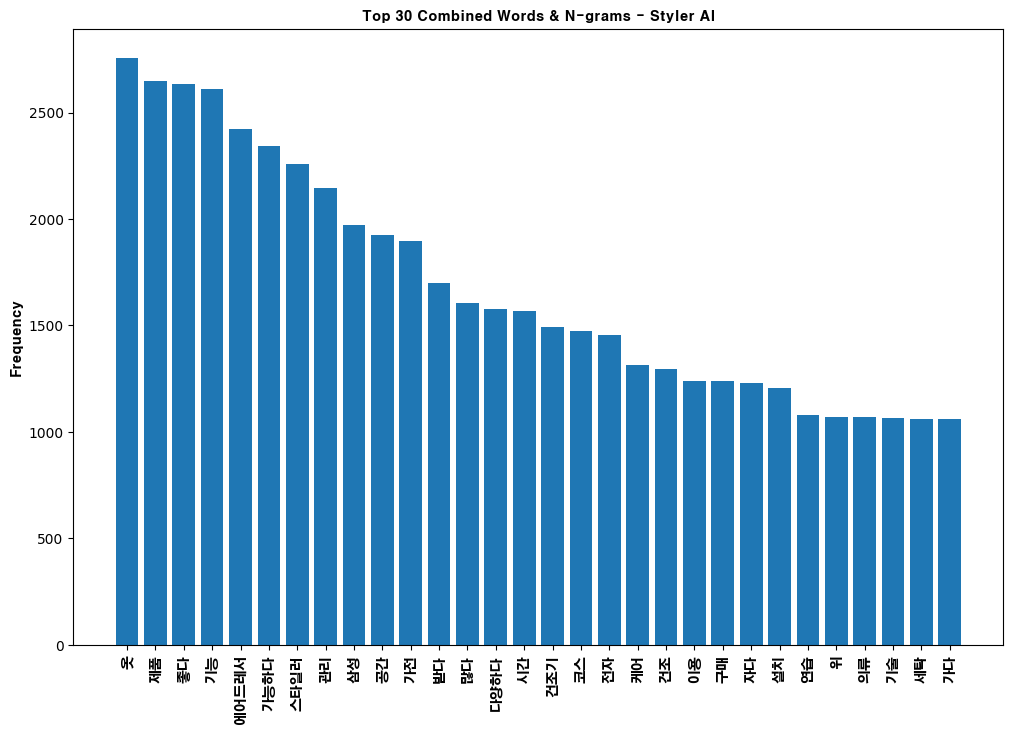

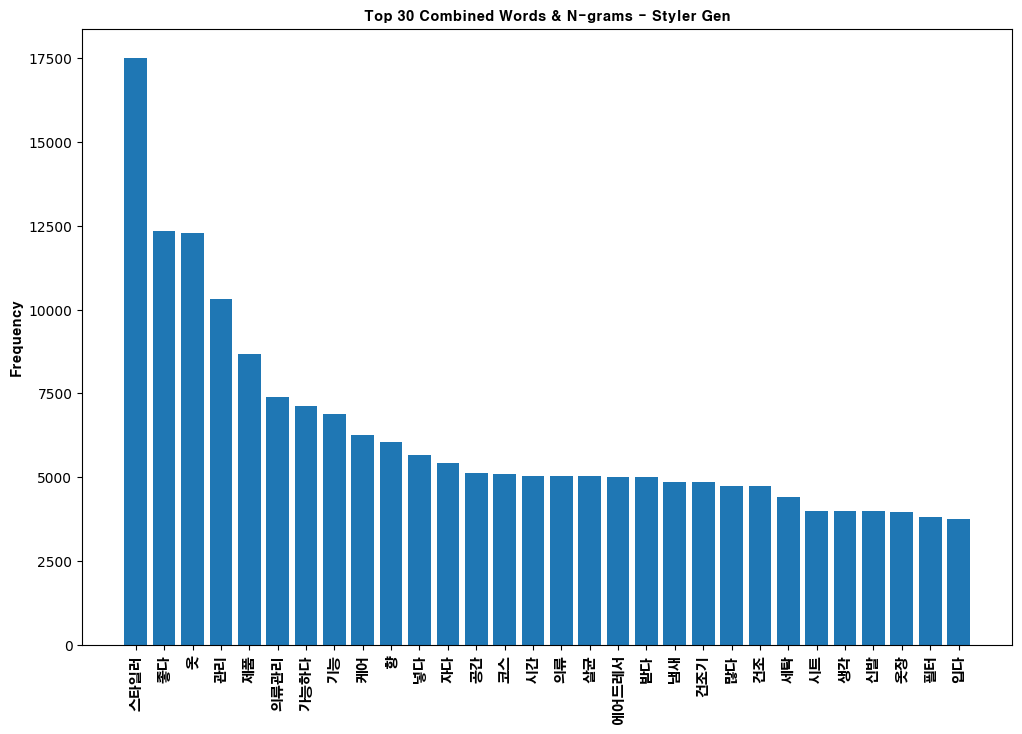

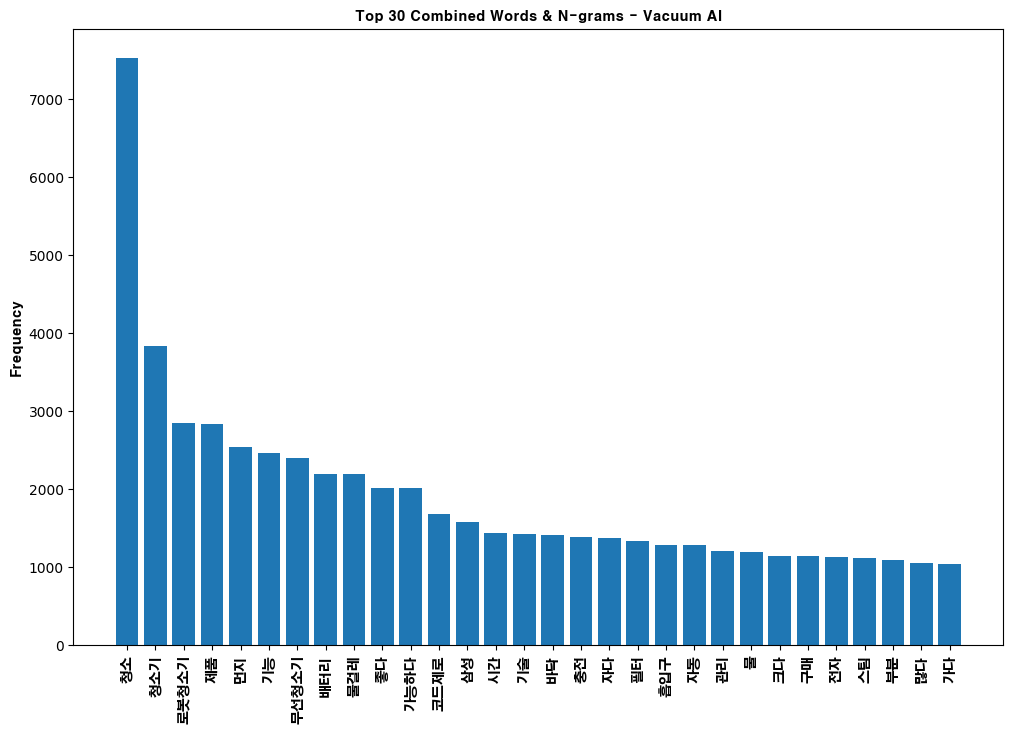

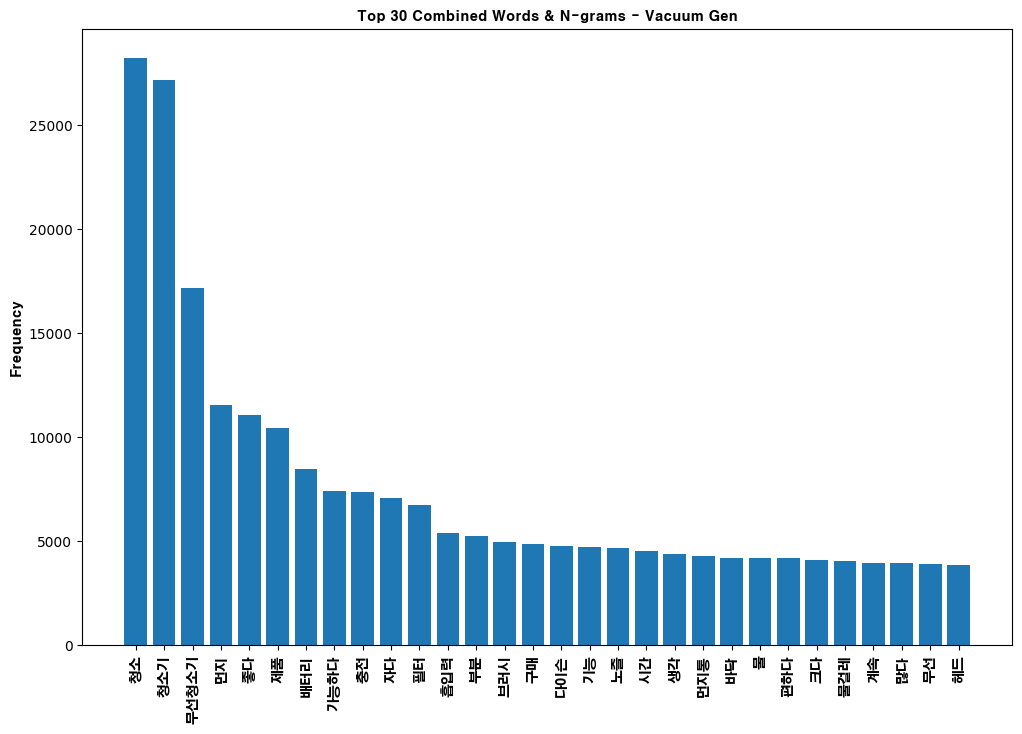

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
from itertools import chain
from matplotlib import font_manager

# 한글 폰트 설정
font_path = "/content/H2GTRE.TTF"  # 한글 폰트 경로
font_prop = font_manager.FontProperties(fname=font_path)

# 빈도 시각화를 위한 함수 정의
def plot_top_combined_frequencies(content, filtered_bigram_freq, filtered_trigram_freq, dataset_name):
    """
    주어진 merged_content와 n-gram 빈도를 기반으로 상위 30개의 단어와 n-gram 빈도를 시각화.
    :param content: merged_content 리스트
    :param filtered_bigram_freq: 필터링된 Bigram 빈도 Counter 객체
    :param filtered_trigram_freq: 필터링된 Trigram 빈도 Counter 객체
    :param dataset_name: 데이터셋 이름 (그래프 제목에 사용)
    """
    # 단어 빈도 계산
    all_tokens = list(chain(*content))
    token_freq = Counter(all_tokens)

    # 단어 빈도와 n-gram 빈도 합치기
    combined_freq = token_freq + filtered_bigram_freq + filtered_trigram_freq

    # 상위 30개 추출
    top_30_combined = combined_freq.most_common(30)

    # 그래프 그리기
    plt.figure(figsize=(12, 8))
    labels, values = zip(*top_30_combined)

    plt.bar(range(len(labels)), values, tick_label=[f'{label}' for label in labels])
    plt.xticks(rotation=90, fontproperties=font_prop)  # 한글 폰트 적용
    plt.title(f"Top 30 Combined Words & N-grams - {dataset_name}", fontproperties=font_prop)
    plt.ylabel("Frequency", fontproperties=font_prop)
    plt.show()

# 각 데이터셋에 대해 그래프 생성
plot_top_combined_frequencies(merged_styler_ai_content, filtered_bigram_freq_styler_ai, filtered_trigram_freq_styler_ai, "Styler AI")
plot_top_combined_frequencies(merged_styler_gen_content, filtered_bigram_freq_styler_gen, filtered_trigram_freq_styler_gen, "Styler Gen")
plot_top_combined_frequencies(merged_vacuum_ai_content, filtered_bigram_freq_vacuum_ai, filtered_trigram_freq_vacuum_ai, "Vacuum AI")
plot_top_combined_frequencies(merged_vacuum_gen_content, filtered_bigram_freq_vacuum_gen, filtered_trigram_freq_vacuum_gen, "Vacuum Gen")


### WordCloud

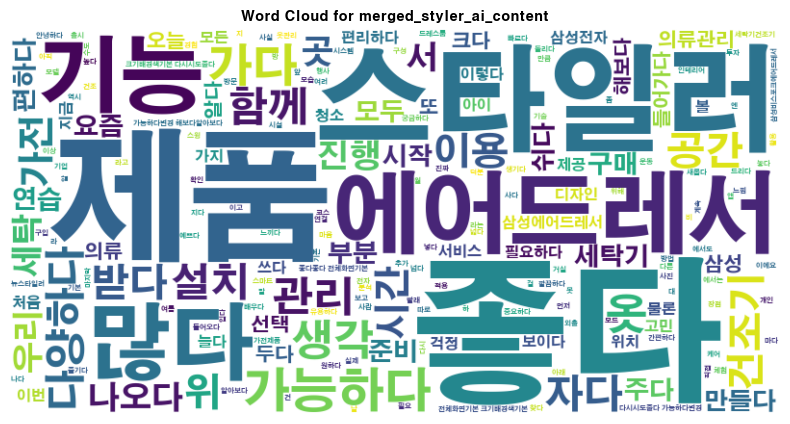

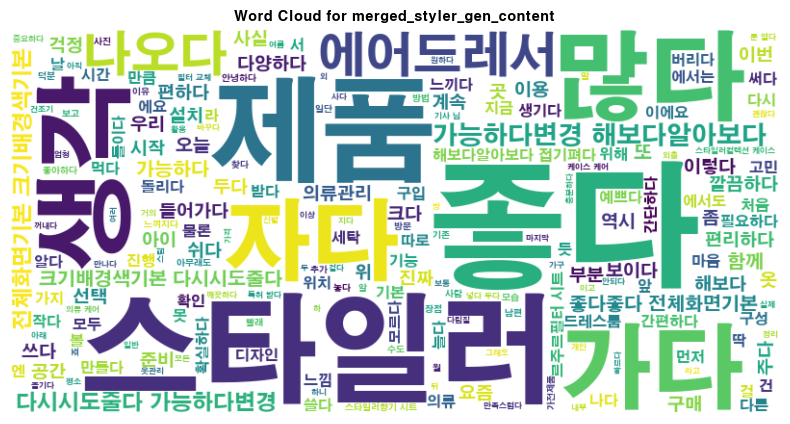

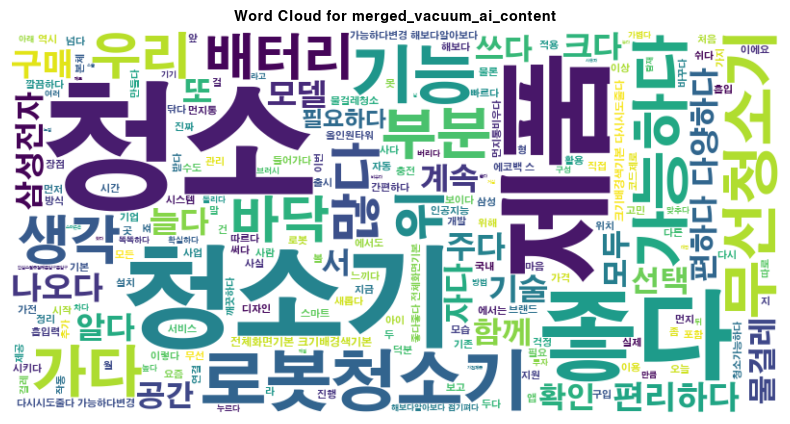

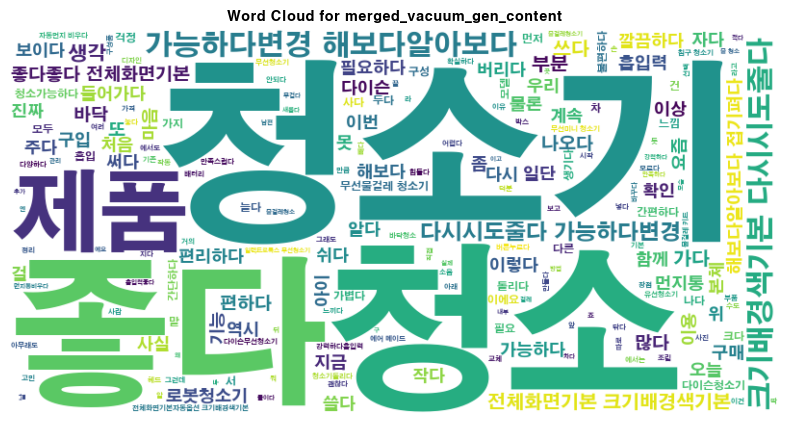

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from itertools import chain

# merged_styler_ai_content, merged_styler_gen_content, merged_vacuum_ai_content, merged_vacuum_gen_content에 대해 워드클라우드 생성

# 리스트를 평탄화하여 하나의 텍스트로 결합하는 함수 정의
def generate_wordcloud(content, title):
    # 리스트 안의 리스트를 평탄화
    flattened_content = list(chain(*content))
    text = " ".join(flattened_content)

    # 워드클라우드 생성
    wordcloud = WordCloud(font_path="/content/H2GTRE.TTF", width=800, height=400, background_color='white').generate(text)

    # 워드클라우드 시각화
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")  # 축 제거
    plt.title(title, fontproperties=font_prop)
    plt.show()

# 각 데이터셋에 대해 워드클라우드 생성
generate_wordcloud(merged_styler_ai_content, "Word Cloud for merged_styler_ai_content")
generate_wordcloud(merged_styler_gen_content, "Word Cloud for merged_styler_gen_content")
generate_wordcloud(merged_vacuum_ai_content, "Word Cloud for merged_vacuum_ai_content")
generate_wordcloud(merged_vacuum_gen_content, "Word Cloud for merged_vacuum_gen_content")


In [ ]:
# ggplot 스타일 설정
#plt.style.use('ggplot')

# 한글 폰트 설정 (예: 나눔고딕)
#font_path = "/content/H2GTRE.TTF"  # 폰트 경로를 설정해주세요
#font_prop = font_manager.FontProperties(fname=font_path)

# 빈도 시각화 (Filtered Bigram)
#plt.figure(figsize=(10, 6))
#bigram_labels, bigram_values = zip(*filtered_bigram_freq.most_common(10))

# 빈도수 바 그래프 그리기
#plt.bar(range(len(bigram_labels)), bigram_values, tick_label=[f'{x[0]}-{x[1]}' for x in bigram_labels])
#plt.xticks(rotation=90, fontproperties=font_prop)  # 한글 폰트 적용
#plt.title("Filtered Top 10 Bigrams", fontproperties=font_prop)
#plt.show()

# 빈도 시각화 (Filtered Trigram)
#plt.figure(figsize=(10, 6))
#trigram_labels, trigram_values = zip(*filtered_trigram_freq.most_common(10))

# 빈도수 바 그래프 그리기
#plt.bar(range(len(trigram_labels)), trigram_values, tick_label=[f'{x[0]}-{x[1]}-{x[2]}' for x in trigram_labels])
#plt.xticks(rotation=90, fontproperties=font_prop)  # 한글 폰트 적용
#plt.title("Filtered Top 10 Trigrams", fontproperties=font_prop)
#plt.show()

In [ ]:
# styler_ai_content에서 각 단어 빈도 계산
# all_tokens = list(chain(*styler_ai_content))  # 모든 토큰을 하나의 리스트로 합침
#all_tokens = list(chain(*merged_styler_ai_content))
#token_freq = Counter(all_tokens)

# n-gram과 단어들을 합친 빈도 분석
#combined_freq = token_freq + filtered_bigram_freq + filtered_trigram_freq

# 상위 30개 빈도 단어 및 n-gram 출력
#top_30_combined = combined_freq.most_common(30)

# ggplot 스타일 설정
#plt.style.use('ggplot')

# 한글 폰트 설정 (예: 나눔고딕)
#font_path = "/content/H2GTRE.TTF"  # 폰트 경로를 설정해주세요
#font_prop = font_manager.FontProperties(fname=font_path)

# 빈도 시각화 (Top 30 Combined)
#plt.figure(figsize=(12, 8))
#labels, values = zip(*top_30_combined)

# 빈도수 바 그래프 그리기
#plt.bar(range(len(labels)), values, tick_label=[f'{label}' for label in labels])
#plt.xticks(rotation=90, fontproperties=font_prop)  # 한글 폰트 적용
#plt.title("Top 30 Combined Words & N-grams", fontproperties=font_prop)
#plt.show()

In [ ]:
# Counter 객체 키를 문자열로 변환
string_combined_freq = {str(key): value for key, value in combined_freq.items()}

# string_combined_freq를 빈도수 기준으로 정렬 (내림차순)
sorted_string_combined_freq = sorted(string_combined_freq.items(), key=lambda x: x[1], reverse=True)

# 상위 10개 출력
print(sorted_string_combined_freq[:10])


[('옷', 970), ('에어드레서', 924), ('스타일러', 695), ('기능', 686), ('제품', 601), ('좋다', 526), ('관리', 517), ('가능하다', 461), ('코스', 445), ('가전', 442)]


## 네트워크 분석

### 단점 네트워크

In [ ]:
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer # DTM
import networkx as nx

In [ ]:
styler_ai_list = [" ".join(inner_list) for inner_list in merged_styler_ai_content]
# styler_ai_list = [" ".join(inner_list) for inner_list in styler_ai_content]

In [ ]:
# 1분 정도 소요
countVectorizer = CountVectorizer()
ai_dtm = countVectorizer.fit_transform(styler_ai_list)
ai_dtm_dense = ai_dtm.todense()
ai_words = countVectorizer.get_feature_names_out()

ai_ttm = np.dot(ai_dtm_dense.T, ai_dtm_dense)
ai_ttm_df = pd.DataFrame(ai_ttm, index=ai_words, columns=ai_words)

{'단점': Text(-0.003798950045879358, 0.009495394891713183, '단점'),
 '사용': Text(0.16479810552966315, 0.027842322319087023, '사용'),
 '시트': Text(-0.06988702502939081, -0.26404934049020234, '시트'),
 '스타일러': Text(-0.21422658595450897, 0.2157854456187581, '스타일러'),
 '관리': Text(0.1837505581806425, 0.2515477483936996, '관리'),
 '기능': Text(-0.04098361945752701, 0.3242394429844117, '기능'),
 '삼성': Text(0.33462883671410504, -0.0919567156504122, '삼성'),
 '에어드레서': Text(-0.2778462545072, -0.14440150533605528, '에어드레서'),
 '해주다': Text(-0.384558857879253, 0.08845062728566232, '해주다'),
 '건조': Text(0.19265486342719174, -0.3142443211138782, '건조'),
 '코스': Text(0.07192246822317373, -0.5046909972955647, '코스'),
 '의류': Text(-0.4004059906581157, -0.3093057429162478, '의류'),
 '되다': Text(0.13920669134783123, 0.5213922651146363, '되다'),
 '구매': Text(-0.5418541459191282, -0.09324956892616641, '구매'),
 '하고': Text(0.2826467194835708, -0.5054621994999556, '하고'),
 '좋다': Text(0.4458254407644444, -0.30874898105607873, '좋다'),
 '보다': Text(

/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from current font.
  func(*ar

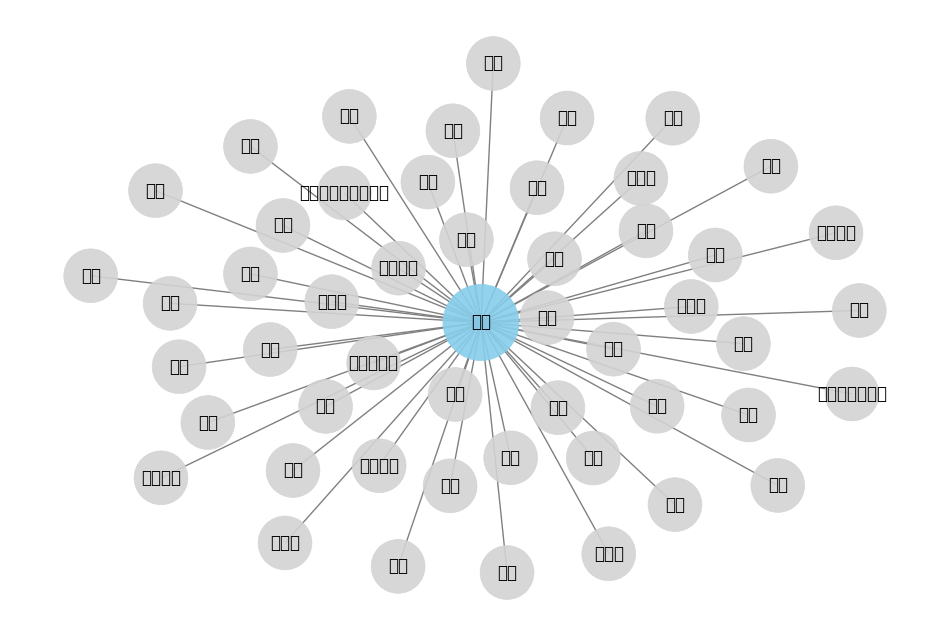

In [ ]:
# 플랏 한글 깨짐 해결
from matplotlib import font_manager
font_location = "/content/H2GTRE.TTF" # 경로설정 필요함
font_name = font_manager.FontProperties(fname=font_location).get_name()

# 데이터프레임 생성
ttm_df = pd.DataFrame(ai_ttm, index=ai_words, columns=ai_words)

# 중심 단어 설정
center_word = "단점"

# 단점과 관계가 높은 상위 50개 단어 선택
related_words = ttm_df[center_word].sort_values(ascending=False).head(51)  # 51개 단어 가져오기
related_words = related_words[related_words.index != center_word]  # '단점' 제외
selected_words = related_words.head(50).index.tolist()  # 상위 50개 단어 선택

# 선택된 단어로 그래프 생성
G = nx.Graph()
for word in selected_words:
    weight = ttm_df[center_word][word]
    if weight > 0:  # 관계가 있는 단어만 추가
        G.add_edge(center_word, word, weight=weight)

# 그래프 시각화
plt.figure(figsize=(12, 8))
ax = plt.gca()  # 현재 축 가져오기
ax.set_facecolor("white")  # 배경색을 흰색으로 설정
plt.axis("off")  # 축 제거

# 노드와 엣지 스타일 설정
pos = nx.spring_layout(G, seed=42, k=0.5)  # 노드 간 간격 조정
node_colors = ["skyblue" if node == center_word else "lightgrey" for node in G.nodes()]
node_sizes = [3000 if node == center_word else 1500 for node in G.nodes()]
edges = G.edges(data=True)
edge_weights = [edge[2]["weight"] for edge in edges]

# 그래프 그리기
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_edges(G, pos, edge_color="gray")
nx.draw_networkx_labels(G, pos, font_size=12, font_family=font_name, font_color="black")

### 브랜드 별

#### 전처리

In [ ]:
# 불용어

stop_words = {'하다', '있다', '되다', '것', '같다', '않다', '이다', '되어다', '기', '저', '후',
             '더', '등', '정말', '이', '때문', '번', '거', '경우', '바로', '그렇다', '분', '안',
             '비', '그', '점', '오브', '제', '요', '전', '저희', '꼭', '글', 'S', '더욱', '기다',
             'CB', '데', '이제', '나', '통해',
              '을', '를', '으로', '에', '수', '습', '가', '들', '은', '도', '는', '와', '아니다',
              '뿐', '인', '슈', '의', '로', '하고',
              '한', '과', '보다', '까지', '에서', '해주다', '없다', '적', '때', '다',
              '만', '중', '에는', '랑', '게'}

In [ ]:
## 5
from nltk.util import ngrams
from collections import Counter

# N-gram 처리
all_bigrams = [bigram for tokens in styler_ai_content for bigram in ngrams(tokens, 2)]

# Bigram 빈도 계산
bigram_freq = Counter(all_bigrams)

# 상위 30개 Bigram 출력
print("Top 30 bigram:")
print(bigram_freq.most_common(30))

In [ ]:
## 6

# N-gram 처리
all_trigrams = [trigram for tokens in styler_ai_content for trigram in ngrams(tokens, 3)]

# Trigram 빈도 계산
trigram_freq = Counter(all_trigrams)

# 상위 30개 Trigram 출력
print("Top 30 Trigram:")
print(trigram_freq.most_common(30))

#### 네트워크 분석

In [ ]:
#! pip install tika

In [ ]:
from tika import parser
from wordcloud import WordCloud
from collections import Counter
from konlpy.tag import Twitter
from konlpy.tag import Okt
from matplotlib import font_manager, rc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import networkx as nx
from itertools import chain

##### styler_ai

In [ ]:
# word_data1 : styler_ai 전처리 후
# word_data2 : styler_gen 전처리 후

words = list(chain.from_iterable(merged_styler_ai_content))
#words = list(chain.from_iterable(styler_ai_content))
count = Counter(words)

word_list = pd.Series(words)
data1 = word_list.value_counts().head(40)

df1 = data1.to_frame()
df1.to_csv('styler_ai_top40.csv')
word_data1 = pd.read_csv('styler_ai_top40.csv', names=['단어','빈도'])

word_data1.dropna(axis=0, inplace=True)
word_data1['styler'] = 'styler_ai'
word_data1

##### styler_gen

In [ ]:
# styler_gen 불용어 추가
stop_words.update(['\n', '\xa0', '싶다', '이렇게'])

In [ ]:
# N-gram 처리
# bigram
all_gen_bigrams = [bigram for tokens in styler_gen_content for bigram in ngrams(tokens, 2)]

# Bigram 빈도 계산
bigram_gen_freq = Counter(all_gen_bigrams)

# 상위 30개 Bigram 출력
print("Top 30 bigram:")
print(bigram_gen_freq.most_common(50))

# N-gram 처리
# trigram
all_gen_trigrams = [trigram for tokens in styler_gen_content for trigram in ngrams(tokens, 3)]

# Trigram 빈도 계산
trigram_gen_freq = Counter(all_gen_trigrams)

# 상위 30개 Trigram 출력
print("Top 30 Trigram:")
print(trigram_gen_freq.most_common(50))

In [ ]:
# words = list(chain.from_iterable(merged_styler_ai_content))
words = list(chain.from_iterable(styler_gen_content))
count = Counter(words)

word_list = pd.Series(words)
data2 = word_list.value_counts().head(40)

df2 = data2.to_frame()
df2.to_csv('styler_gen_top40.csv')
word_data2 = pd.read_csv('styler_gen_top40.csv', names=['단어','빈도'])

word_data2.dropna(axis=0, inplace=True)
word_data2['styler'] = 'styler_gen'
word_data2

##### 시각화

In [ ]:
dataframe = pd.concat([word_data1, word_data2], ignore_index=True)
dataframe

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
import networkx as nx

# 한글 폰트 설정
#font_path = "~/Fonts/NanumBarunGothic.ttf"  # 폰트 경로
font_path = "/content/H2GTRE.TTF"
font_prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['axes.unicode_minus'] = False  # 한글 깨짐 방지

In [ ]:
## 네트워크 그래프

g = nx.karate_club_graph()
g = nx.from_pandas_edgelist(dataframe, source='단어', target='styler')
pos = nx.spring_layout(g, k=0.7, iterations=200, scale=2)

color_map_node=[]
node_size_map = []
for node in g:
    if node == 'styler_gen':
        color_map_node.append('lightcoral')
        node_size_map.append(2000)
    elif node == 'styler_ai':
        color_map_node.append('cornflowerblue')
        node_size_map.append(2000)
    else:
        color_map_node.append('white')
        node_size_map.append(1000)

color_map_edge=[]
for edges in g.edges():
    if 'styler_gen' in edges:
        color_map_edge.append('lightcoral')
    if 'styler_ai' in edges:
        color_map_edge.append('cornflowerblue')

plt.figure(figsize=(15, 15))

nx.draw_networkx_nodes(g, pos, node_size=node_size_map, node_color=color_map_node)
nx.draw_networkx_edges(g, pos, width=1, edge_color = color_map_edge)

# 노드 라벨 추가 (한글 폰트 적용)
labels = {node: str(node) for node in g.nodes()}  # 노드 이름 매핑
for key, (x, y) in pos.items():
    plt.text(x, y, labels[key], fontsize=20, fontproperties=font_prop, ha='center', va='center')

plt.show()

### input: n-gram

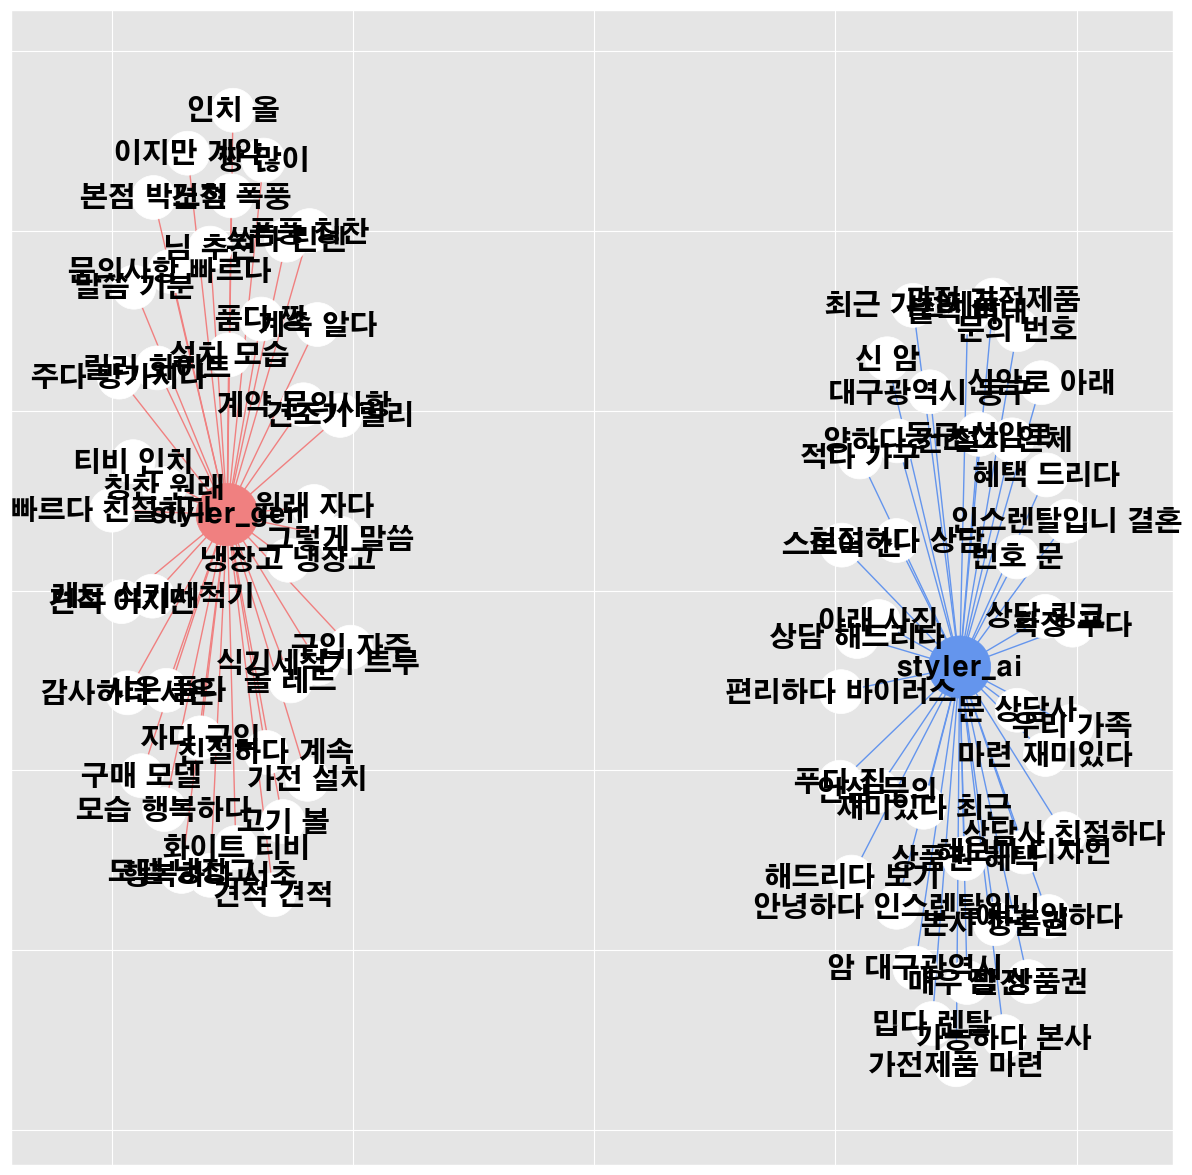

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib import font_manager
import networkx as nx
import pandas as pd
from itertools import chain
from nltk.util import ngrams

# Bigram 처리 후 빈도 계산
all_bigrams = [bigram for tokens in styler_ai_content for bigram in ngrams(tokens, 2)]
all_gen_bigrams = [bigram for tokens in styler_gen_content for bigram in ngrams(tokens, 2)]

# Bigram 빈도 계산
bigram_styler_ai_freq = Counter(all_bigrams)
bigram_styler_gen_freq = Counter(all_gen_bigrams)

# Bigram을 하나의 단어처럼 취급하여 빈도 계산
bigram_styler_ai_words = [' '.join(bigram) for bigram in bigram_styler_ai_freq.keys()]
bigram_styler_gen_words = [' '.join(bigram) for bigram in bigram_styler_gen_freq.keys()]

# 상위 40개의 Bigram 추출
data_styler_ai = pd.Series(bigram_styler_ai_words).value_counts().head(40)
data_styler_gen = pd.Series(bigram_styler_gen_words).value_counts().head(40)

# DataFrame으로 변환
df_styler_ai = data_styler_ai.to_frame().reset_index()
df_styler_ai.columns = ['단어', '빈도']
df_styler_ai['styler'] = 'styler_ai'

df_styler_gen = data_styler_gen.to_frame().reset_index()
df_styler_gen.columns = ['단어', '빈도']
df_styler_gen['styler'] = 'styler_gen'

# 두 DataFrame을 합침
dataframe = pd.concat([df_styler_ai, df_styler_gen], ignore_index=True)

# 한글 폰트 설정
font_path = "/content/H2GTRE.TTF"
font_prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['axes.unicode_minus'] = False  # 한글 깨짐 방지

# 네트워크 그래프
g = nx.Graph()

# DataFrame을 기반으로 그래프의 노드와 엣지 추가
for _, row in dataframe.iterrows():
    word = row['단어']
    styler = row['styler']

    # Bigram을 하나의 노드로 취급
    g.add_node(word, weight=row['빈도'])

    # styler와 연결된 엣지 추가
    g.add_edge(word, styler, weight=row['빈도'])

# 노드 위치 설정
pos = nx.spring_layout(g, k=0.7, iterations=200, scale=2)

# 노드 및 엣지 색상 설정
color_map_node = []
node_size_map = []
for node in g:
    if node == 'styler_gen':
        color_map_node.append('lightcoral')
        node_size_map.append(2000)
    elif node == 'styler_ai':
        color_map_node.append('cornflowerblue')
        node_size_map.append(2000)
    else:
        color_map_node.append('white')
        node_size_map.append(1000)

color_map_edge = []
for edges in g.edges():
    if 'styler_gen' in edges:
        color_map_edge.append('lightcoral')
    if 'styler_ai' in edges:
        color_map_edge.append('cornflowerblue')

# 그래프 시각화
plt.figure(figsize=(15, 15))
nx.draw_networkx_nodes(g, pos, node_size=node_size_map, node_color=color_map_node)
nx.draw_networkx_edges(g, pos, width=1, edge_color=color_map_edge)

# 노드 라벨 추가 (한글 폰트 적용)
labels = {node: str(node) for node in g.nodes()}  # 노드 이름 매핑
for key, (x, y) in pos.items():
    plt.text(x, y, labels[key], fontsize=20, fontproperties=font_prop, ha='center', va='center')

plt.show()


## 토픽모델링

* 3개의 토픽

    * Topic #1: 의류관리기 사용 경험과 관련된 내용 (주로 스타일러, 기능, 관리, 구매 경험).
    
      스타일러 에어드레서 좋다 가전 구매 넣다 돌리다 자다 생각 기능 입다 관리 거울 많다 너무 고민 세탁 가능하다 후기 들다

    * Topic #2: 기능 및 의류 관리 (미세먼지 제거, 의류 관리, 살균 기능).

      에어드레서 기능 제품 관리 제거 가능하다 의류 코스 미세먼지 삼성에어드레서 공간 의류관리 살균 편리하다 삼성 선택 디자인 옷관리 냄새 스팀
      
    * Topic #3: 건조기 및 세탁기 역할 대체 관련된 내용 (세탁기, 건조기 사용 불필요 -> 시간 절약)

      건조기 건조 세탁 제품 빨래 기능 받다 골프 세탁기 살균 작동 시트 시간 좋다 코스 들다 내부 필터 세탁기건조기 설치


      

In [ ]:
# !pip install pyLDAvis
# !pip install pyLDAvis==3.3.1
#!pip install pyLDAvis[support]
#!pip install -U scikit-learn
#!pip install pyLDAvis

In [ ]:
# merged_styler_ai_content[:1]

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 한글 폰트 설정
font_path = '/content/H2GTRE.TTF'  # 한글 폰트 경로 설정
font_prop = font_manager.FontProperties(fname=font_path)

### 의류관리기 AI

* merged_styler_ai_content

In [ ]:
# 텍스트 데이터를 단어 빈도수 벡터로 변환
vectorizer_styler_ai = CountVectorizer(stop_words='english')

#styler_ai_content_str = [" ".join(tokens) for tokens in styler_ai_content]
merged_styler_ai_content_str = [" ".join(tokens) for tokens in merged_styler_ai_content]
X_styler_ai = vectorizer_styler_ai.fit_transform(merged_styler_ai_content_str)


# LDA 모델 학습
lda_styler_ai = LatentDirichletAllocation(n_components=3, random_state=42)
lda_styler_ai.fit(X_styler_ai)

# 각 토픽에 대해 중요한 단어 추출
words_styler_ai = vectorizer_styler_ai.get_feature_names_out()
topic_words_styler_ai = []
for topic in lda_styler_ai.components_:
    topic_words_styler_ai.append([words_styler_ai[i] for i in topic.argsort()[:-16:-1]])

print(topic_words_styler_ai)

[['에어드레서', '좋다', '스타일러', '가전', '구매', '넣다', '생각', '자다', '돌리다', '기능', '들다', '설치', '거울', '많다', '고민'], ['제품', '에어드레서', '살균', '기능', '건조', '제거', '코스', '가능하다', '건조기', '의류', '삼성', '공간', '관리', '미세먼지', '삼성에어드레서'], ['스타일러', '기능', '관리', '의류관리', '다양하다', '코스', '옷관리', '기술', '제품', '전자', '의류', '가능하다', '뉴스타일러', '스팀', '늘다']]


In [ ]:
# 주제별 상위 단어 출력
for topic_idx, topic in enumerate(lda_styler_ai.components_):
    print(f"Topic #{topic_idx + 1}:")
    print(" ".join([vectorizer_styler_ai.get_feature_names_out()[i] for i in topic.argsort()[:-20 - 1:-1]]))

Topic #1:
에어드레서 좋다 스타일러 가전 구매 넣다 생각 자다 돌리다 기능 들다 설치 거울 많다 고민 후기 냄새 받다 입다 사다
Topic #2:
제품 에어드레서 살균 기능 건조 제거 코스 가능하다 건조기 의류 삼성 공간 관리 미세먼지 삼성에어드레서 케어 필터 세탁 먼지 가전
Topic #3:
스타일러 기능 관리 의류관리 다양하다 코스 옷관리 기술 제품 전자 의류 가능하다 뉴스타일러 스팀 늘다 편리하다 세탁 컬렉션스타일러 선택 소재


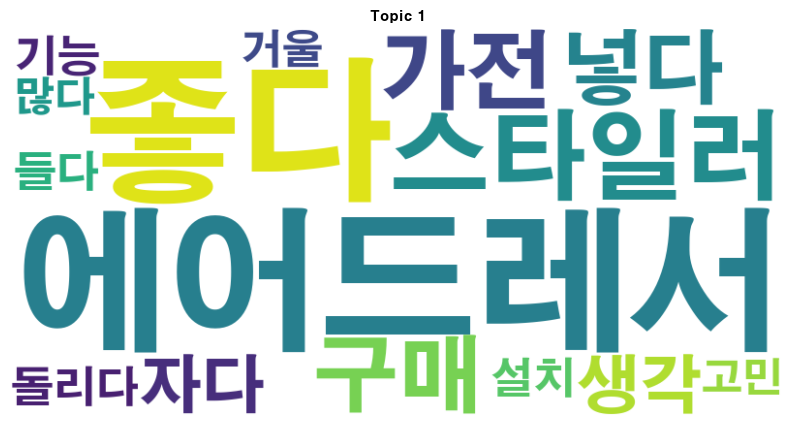

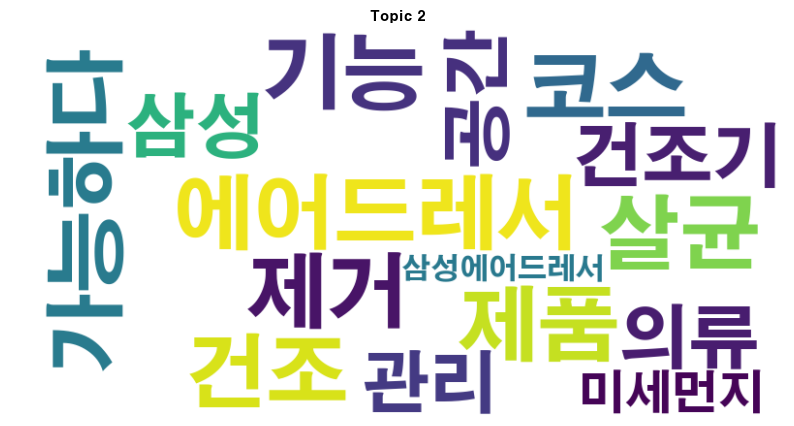

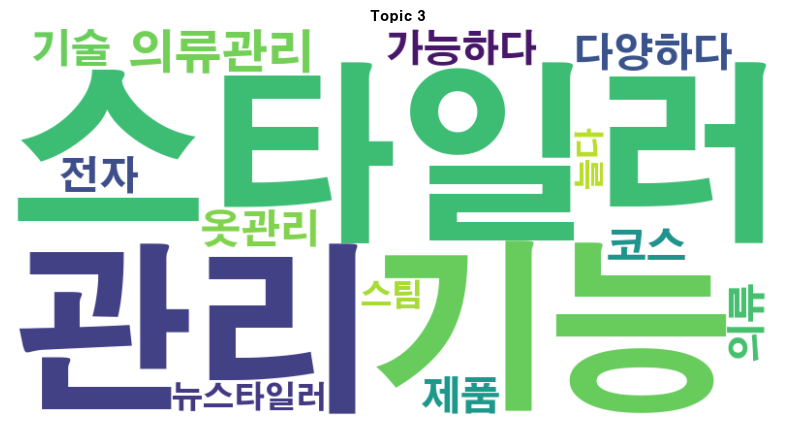

In [ ]:
# WordCloud 시각화 함수
def plot_wordcloud(words_list):
    for idx, topic in enumerate(words_list):
        wordcloud = WordCloud(
            width=800, height=400, background_color='white',
            font_path=font_path).generate(" ".join(topic))  # 한글 폰트 적용
        plt.figure(figsize=(10, 6))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis("off")
        plt.title(f"Topic {idx+1}", fontsize=16, fontproperties=font_prop)
        plt.show()

# WordCloud 시각화
plot_wordcloud(topic_words_styler_ai)


### 의류관리기 gen

* merged_styler_gen_content

In [ ]:
# 텍스트 데이터를 단어 빈도수 벡터로 변환
vectorizer_styler_gen = CountVectorizer(stop_words='english')

#styler_ai_content_str = [" ".join(tokens) for tokens in styler_ai_content]
merged_styler_gen_content_str = [" ".join(tokens) for tokens in merged_styler_gen_content]
X_styler_gen = vectorizer_styler_gen.fit_transform(merged_styler_gen_content_str)


# LDA 모델 학습
lda_styler_gen = LatentDirichletAllocation(n_components=4, random_state=42)
lda_styler_gen.fit(X_styler_gen)

# 각 토픽에 대해 중요한 단어 추출
words_styler_gen = vectorizer_styler_gen.get_feature_names_out()
topic_words_styler_gen = []
for topic in lda_styler_gen.components_:
    topic_words_styler_gen.append([words_styler_gen[i] for i in topic.argsort()[:-16:-1]])

print(topic_words_styler_gen)

[['관리', '코스', '건조', '스타일러컬렉션', '의류관리', '의류', '기능', '세탁', '살균', '시간', '스타일러', '건조기', '후기', '스팀살균', '신발'], ['옷장', '향기', '좋다', '제품', '관리', '넣다', '탈취', '스타일러', '가능하다', '살균', '에어락', '의류관리', '냄새', '주름', '효과'], ['제품', '관리', '기능', '스타일러', '의류', '필터', '에어드레서', '살균', '건조', '의류관리', '미세먼지', '가능하다', '제거', '시간', '먼지'], ['스타일러', '좋다', '돌리다', '자다', '넣다', '에어드레서', '구매', '가전', '생각', '시트', '입다', '건조기', '기능', '쓰다', '냄새']]


In [ ]:
# 주제별 상위 단어 출력
for topic_idx, topic in enumerate(lda_styler_gen.components_):
    print(f"Topic #{topic_idx + 1}:")
    print(" ".join([vectorizer_styler_gen.get_feature_names_out()[i] for i in topic.argsort()[:-20 - 1:-1]]))

Topic #1:
관리 코스 건조 스타일러컬렉션 의류관리 의류 기능 세탁 살균 시간 스타일러 건조기 후기 스팀살균 신발 가전 케어 아이 바이러스 업체
Topic #2:
옷장 향기 좋다 제품 관리 넣다 탈취 스타일러 가능하다 살균 에어락 의류관리 냄새 주름 효과 제거 걸다 순환 스팀 공간
Topic #3:
제품 관리 기능 스타일러 의류 필터 에어드레서 살균 건조 의류관리 미세먼지 가능하다 제거 시간 먼지 에어 좋다 냄새 옷걸이 공간
Topic #4:
스타일러 좋다 돌리다 자다 넣다 에어드레서 구매 가전 생각 시트 입다 건조기 기능 쓰다 냄새 들다 아로마시트 패딩 겨울 고민


### 무선스틱청소기 AI

* merged_vacuum_ai_content

In [ ]:
# 텍스트 데이터를 단어 빈도수 벡터로 변환
vectorizer_vacuum_ai = CountVectorizer(stop_words='english')

#styler_ai_content_str = [" ".join(tokens) for tokens in styler_ai_content]
merged_vacuum_ai_content_str = [" ".join(tokens) for tokens in merged_vacuum_ai_content]
X_vacuum_ai = vectorizer_vacuum_ai.fit_transform(merged_vacuum_ai_content_str)


# LDA 모델 학습
lda_vacuum_ai = LatentDirichletAllocation(n_components=3, random_state=42)
lda_vacuum_ai.fit(X_vacuum_ai)

# 각 토픽에 대해 중요한 단어 추출
words_vacuum_ai = vectorizer_vacuum_ai.get_feature_names_out()
topic_words_vacuum_ai = []
for topic in lda_vacuum_ai.components_:
    topic_words_vacuum_ai.append([words_vacuum_ai[i] for i in topic.argsort()[:-16:-1]])

print(topic_words_vacuum_ai)

[['줄다', '제품', '청소', '청소기', '분리', '배터리', '필터', '먼지', '음악', '브러시', '먼지통', '본체', '충전', '설정', '전자코드'], ['청소', '코드제로', '청소기', '안심스팀', '무선청소기', '물걸레', '좋다', '먼지', '바닥', '가능하다', '흡입구', '올인원타워', '기능', '스팀', '스팀물걸레'], ['청소기', '청소', '무선청소기', '배터리', '제품', '먼지', '기능', '좋다', '흡입력', '구매', '삼성', '물걸레', '충전', '자다', '제트']]


In [ ]:
# 주제별 상위 단어 출력
for topic_idx, topic in enumerate(lda_vacuum_ai.components_):
    print(f"Topic #{topic_idx + 1}:")
    print(" ".join([vectorizer_vacuum_ai.get_feature_names_out()[i] for i in topic.argsort()[:-20 - 1:-1]]))

Topic #1:
줄다 제품 청소 청소기 분리 배터리 필터 먼지 음악 브러시 먼지통 본체 충전 설정 전자코드 청정스테이션 모드 버튼누르다 전원 다시
Topic #2:
청소 코드제로 청소기 안심스팀 무선청소기 물걸레 좋다 먼지 바닥 가능하다 흡입구 올인원타워 기능 스팀 스팀물걸레 컬렉션 자다 흡입 구매 제품
Topic #3:
청소기 청소 무선청소기 배터리 제품 먼지 기능 좋다 흡입력 구매 삼성 물걸레 충전 자다 제트 생각 부분 먼지통 가능하다 자동


### 무선스틱청소기 gen

* merged_vacuum_gen_content

In [ ]:
# 텍스트 데이터를 단어 빈도수 벡터로 변환
vectorizer_vacuum_gen = CountVectorizer(stop_words='english')

#styler_ai_content_str = [" ".join(tokens) for tokens in styler_ai_content]
merged_vacuum_gen_content_str = [" ".join(tokens) for tokens in merged_vacuum_gen_content]
X_vacuum_gen = vectorizer_vacuum_gen.fit_transform(merged_vacuum_gen_content_str)


# LDA 모델 학습
lda_vacuum_gen = LatentDirichletAllocation(n_components=4, random_state=42)
lda_vacuum_gen.fit(X_vacuum_gen)

# 각 토픽에 대해 중요한 단어 추출
words_vacuum_gen = vectorizer_vacuum_gen.get_feature_names_out()
topic_words_vacuum_gen = []
for topic in lda_vacuum_gen.components_:
    topic_words_vacuum_gen.append([words_vacuum_gen[i] for i in topic.argsort()[:-16:-1]])

print(topic_words_vacuum_gen)

[['배터리', '청소기', '필터', '교체', '청소', '먼지통', '분리', '먼지', '제품', '부분', '서비스', '자다', '삼성', '센터', '헤드'], ['청소', '다이슨', '청소기', '제품', '브러시', '디지털', '자다', '롤러', '모드', '플러피', '들다', '무선스틱청소기', '소프트', '다이슨무선', '먼지'], ['청소', '무선청소기', '먼지', '청소기', '일렉트로룩스', '노즐', '좋다', '가능하다', '제품', '필터', '충전', '흡입력', '모터', '편하다', '틈새'], ['청소기', '청소', '무선청소기', '좋다', '제품', '구매', '먼지', '자다', '흡입력', '물걸레', '생각', '다이슨', '쓰다', '들다', '가격']]


In [ ]:
# 주제별 상위 단어 출력
for topic_idx, topic in enumerate(lda_vacuum_gen.components_):
    print(f"Topic #{topic_idx + 1}:")
    print(" ".join([vectorizer_vacuum_gen.get_feature_names_out()[i] for i in topic.argsort()[:-20 - 1:-1]]))

Topic #1:
배터리 청소기 필터 교체 청소 먼지통 분리 먼지 제품 부분 서비스 자다 삼성 센터 헤드 충전 줄다 수리 다이슨 방법
Topic #2:
청소 다이슨 청소기 제품 브러시 디지털 자다 롤러 모드 플러피 들다 무선스틱청소기 소프트 다이슨무선 먼지 다양하다 시간 성능 주다 가지
Topic #3:
청소 무선청소기 먼지 청소기 일렉트로룩스 노즐 좋다 가능하다 제품 필터 충전 흡입력 모터 편하다 틈새 미세먼지 브러쉬 디자인 퓨어 집안
Topic #4:
청소기 청소 무선청소기 좋다 제품 구매 먼지 자다 흡입력 물걸레 생각 다이슨 쓰다 들다 가격 가볍다 충전 배터리 기능 후기


# 미완성

## 감정분석

* 대부분 후기가 긍정

* 부정적인 후기 수 너무 적음

    * 있어도 대부분 긍정적 후기에 약간의 번거로움, 단점 등 언급

In [ ]:
import json
import pandas as pd
from konlpy.tag import Okt
from collections import Counter
import json
import pandas as pd
import requests

# SentiWord_info.json 파일 URL (GitHub에서 제공하는 URL)
url = "https://raw.githubusercontent.com/park1200656/KnuSentiLex/master/KnuSentiLex/data/SentiWord_info.json"

# 파일 다운로드
response = requests.get(url)

# 파일이 성공적으로 다운로드되었는지 확인
if response.status_code == 200:
    # JSON 데이터 로드
    SentiWord_info = response.json()

    # SentiWord 정보를 DataFrame으로 변환
    sentiword_dic = pd.DataFrame(SentiWord_info)

    # 결과 확인
    print(sentiword_dic.head())
else:
    print(f"파일 다운로드 실패: {response.status_code}")

# styler_ai의 content 열을 가져옴
# styler_ai_content = styler_ai['content']

# Okt 객체 초기화
#okt = Okt()

# content 열의 토큰화
#tokens = [okt.morphs(word) for word in styler_ai_content]
#tokens = list(map(lambda x: " ".join(x), tokens))

# 감성 분석 함수 정의
def sentiment_analysis(tokens):
    sentiment = 0  # 초기 감성값 0으로 설정
    for i in range(0, len(sentiword_dic)):  # 감성사전의 모든 단어를 하나씩 선택
        if sentiword_dic.word[i] in tokens:  # 리뷰 문장에 감성 단어가 있는지 확인
            sentiment += int(sentiword_dic.polarity[i])  # 감성단어가 있다면 극성값 합계 계산
    return sentiment

# 감성 분석을 통해 sentiment 열 생성
sentiments = [sentiment_analysis(token) for token in styler_ai_content]

# 감성 분석 결과를 styler_ai에 추가
styler_ai['sentiment'] = sentiments

# 결과 확인
# styler_ai[['content', 'sentiment']].head()

# 추가적으로, Top N-gram 분석을 통한 감성 분석을 합쳐 보겠습니다.

from collections import Counter
from konlpy.tag import Okt
from nltk import ngrams

# 상위 빈도 Bigram, Trigram을 분석할 n-gram 데이터 생성
# top_bigrams = [bigram for bigram, _ in bigram_freq.most_common(30)]
# top_trigrams = [trigram for trigram, _ in trigram_freq.most_common(30)]

# 병합된 단어로 토큰화
# merged_styler_ai_content = [merge_top_ngrams(tokens, top_bigrams + top_trigrams) for tokens in styler_ai_content]

# 감성 분석을 통한 'sentiment' 열 생성 후 `styler_ai`에 반영
sentiments_merged = [sentiment_analysis(" ".join(merged_tokens)) for merged_tokens in merged_styler_ai_content]

# 결과를 styler_ai에 추가
styler_ai['merged_sentiment'] = sentiments_merged

# 최종 결과 확인
styler_ai[['content', 'sentiment', 'merged_sentiment']].head()


    word word_root polarity
0    (-;         (        1
1  (;_;)     (;_;)       -1
2   (^^)      (^^)        1
3  (^-^)     (^-^)        1
4   (^^*         (        1


,content,sentiment,merged_sentiment
0,우리 가족이 사용한다는 마음으로 정성을 다해 리뷰하는 유여사 있니다 스타일리시한 나...,21,22
1,안녕하세요 이 영상에서는 2024년 출시된 LG 스타일러 오브젝트 컬렉션 올 뉴 s...,20,25
2,LG 스타일러 오브제컬렉션 신제품 올 뉴 스타일러 빌트인 고압 스티머 의류관리기안...,18,24
3,한번 보면 계속 찾아보게 되는 #나는솔로 ~ 뒷 내용이 궁금해서 한 번에 몰아보기를...,16,20
4,본 포스팅은 LG전자로부터 소정의 원고료를 제공받아 작성되었습니다. LG 올 뉴 스...,19,21


Sentiment 감정 분석 결과:
sentiment_class
긍정    292
부정     16
중립     11
Name: count, dtype: int64

Merged Sentiment 감정 분석 결과:
merged_sentiment_class
긍정    278
부정     33
중립      8
Name: count, dtype: int64


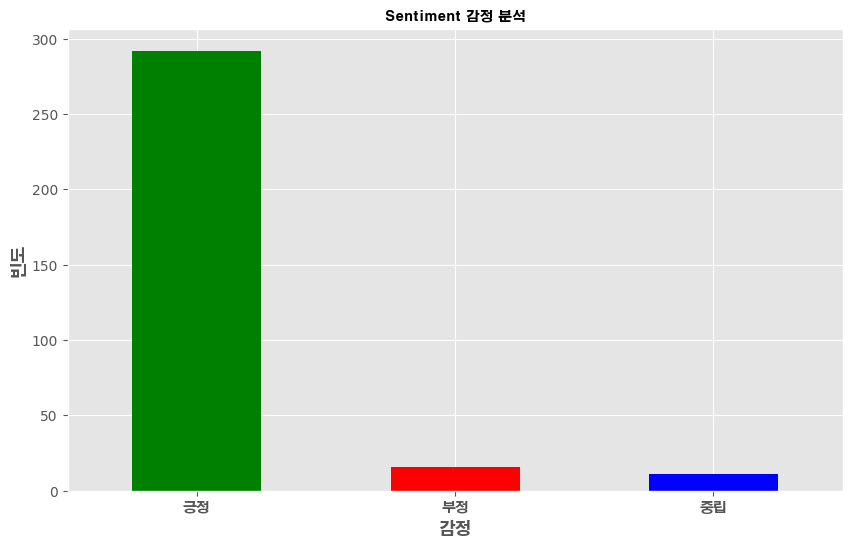

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.10/dist-packages/matplotlib/pyplot.py'>

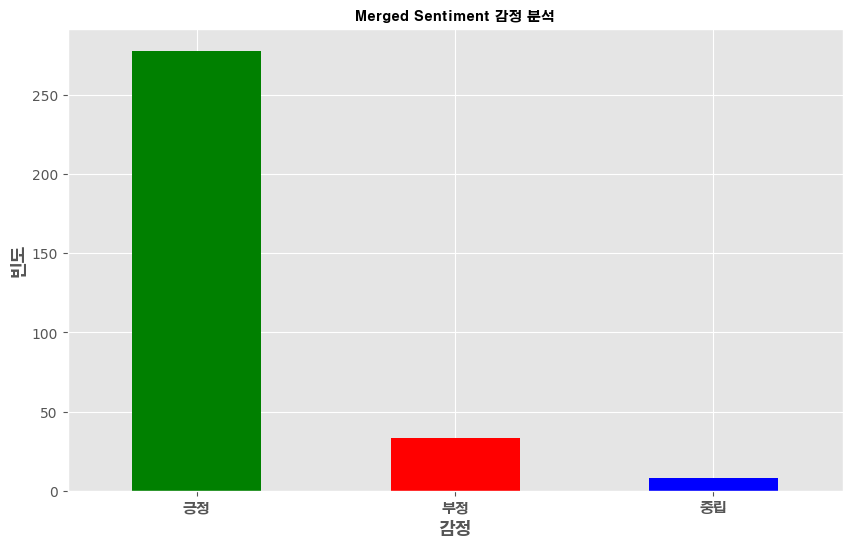

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 한글 폰트 설정 (예: H2GTRE.TTF)
font_path = "/content/H2GTRE.TTF"  # 폰트 경로를 설정해주세요
font_prop = font_manager.FontProperties(fname=font_path)

# 감정 분석 기준 함수
def classify_sentiment(value):
    if value > 0:
        return '긍정'
    elif value < 0:
        return '부정'
    else:
        return '중립'

# sentiment와 merged_sentiment에 대한 감정 분류
styler_ai['sentiment_class'] = styler_ai['sentiment'].apply(classify_sentiment)
styler_ai['merged_sentiment_class'] = styler_ai['merged_sentiment'].apply(classify_sentiment)

# sentiment와 merged_sentiment의 감정 분석 표
sentiment_counts = styler_ai['sentiment_class'].value_counts()
merged_sentiment_counts = styler_ai['merged_sentiment_class'].value_counts()

# 결과 출력 (표)
print("Sentiment 감정 분석 결과:")
print(sentiment_counts)
print("\nMerged Sentiment 감정 분석 결과:")
print(merged_sentiment_counts)

# 시각화 (sentiment)
plt.figure(figsize=(10, 6))
sentiment_counts.plot(kind='bar', color=['green', 'red', 'blue'])
plt.title('Sentiment 감정 분석', fontsize=16, fontproperties=font_prop)
plt.xlabel('감정', fontsize=12, fontproperties=font_prop)
plt.ylabel('빈도', fontsize=12, fontproperties=font_prop)
plt.xticks(rotation=0, fontproperties=font_prop)
plt.show()

# 시각화 (merged_sentiment)
plt.figure(figsize=(10, 6))
merged_sentiment_counts.plot(kind='bar', color=['green', 'red', 'blue'])
plt.title('Merged Sentiment 감정 분석', fontsize=16, fontproperties=font_prop)
plt.xlabel('감정', fontsize=12, fontproperties=font_prop)
plt.ylabel('빈도', fontsize=12, fontproperties=font_prop)
plt.xticks(rotation=0, fontproperties=font_prop)
plt


In [ ]:
# sentiment_class가 '부정'인 데이터 출력
styler_ai[styler_ai['sentiment_class'] == '부정']


,title,content,date,link,platform,sentiment,merged_sentiment,sentiment_class,merged_sentiment_class
52,스타일러 추천,스타일러 추천해당 사진을 클릭하시면 더욱 자세한 제품 정보를 보실수 있습니다.1위 ...,2023-03-31,https://blog.naver.com/siki1112/223060602388,blog,-2,-7,부정,부정
53,LG엘지전자 TV 스타일러 김치냉장고 세탁기 건조기 로봇청소기,🔥10월 경주하이마트🔥가전제품 할인 행사 삼성전자 LG엘지전자 TV 스타일러 김치냉...,2023-10-01,https://blog.naver.com/ghost2608/223225779692,blog,-1,-8,부정,부정
92,삼성 비스포크 에어드레서... 한번에하는 AI 섬세 건조,"삼성 비스포크 에어드레서 상의 3벌, 바지 3벌 DF60A8500EG 삼성전자 비...",2024-10-11,https://blog.naver.com/mrrqgtl9111/223615081271,blog,-4,-7,부정,부정
104,DF10C9500CG 삼성비스포크 에어드레서 행사 / 하이마트 삼성...,안녕하세요!대구 가전 NO.1범어네거리점하이마트입니다! 오늘 소개해 드릴 행사모델은...,2024-06-16,https://blog.naver.com/mnasd123/223480983381,blog,-4,-2,부정,부정
147,삼성전자 BESPOKE 에어드레서 우리衣취향 체험단,삼성전자 BESPOKE 에어드레서우리衣취향 체험단 우리 신혼집 옷방이랍니다.행...,2023-03-26,https://blog.naver.com/viky61/223056135698,blog,-4,-4,부정,부정
159,"BESPOKE 의류케어, 우리집 사계절 옷을 에어드레서에 맡긴다!",#BESPOKE의류케어가전메이크오버체험단 #삼성메이크오버체험단 #메이크오버이벤트 #...,2022-10-17,https://blog.naver.com/white891004/222902546271,blog,-1,-5,부정,부정
189,LG [SC5GMR80H] 스타일러 오브제컬렉션 (ALL NEW) 5벌+바지 1벌,"안녕하세요, 이전 스탠바이미와 같이 제가 LG로 가전을 맞추게 된 결정적인 제품을 ...",2024-10-23,https://cafe.naver.com/directwedding/ca-fe/Art...,naver cafe,-8,-14,부정,부정
208,우리집 옷을 뽀송하게! LG 스타일러 SC5GMR60,다들 스타일러 하셨나요?? 저희는 가전을 구매할때 두번째로 의견이 달랐던게 바로 요...,2024-08-03,https://cafe.naver.com/directwedding/ca-fe/Art...,naver cafe,-2,-2,부정,부정
214,LG 스타일러 오브제 SC5MBR60 후기,LG 오브제 스타일러 후기 스타일러 한번도 안써봐서 왜 써야하는지 몰랐던 1인 처음...,2024-07-17,https://cafe.naver.com/directwedding/ca-fe/Art...,naver cafe,-1,-2,부정,부정
230,LG전자 오브제컬렉션 스타일러 SC5MBR60 사용후기,안녕하세요! 저는 요즘 신혼가전의 필수품! 이라는 스타일러를 구매했습니다! 24년...,2024-04-27,https://cafe.naver.com/directwedding/ca-fe/Art...,naver cafe,-2,-1,부정,부정


In [ ]:
# merged_sentiment_class가 '긍정'인 데이터 출력
styler_ai[styler_ai['merged_sentiment_class'] == '긍정']

In [ ]:
from transformers import pipeline

# 대체 모델 로드
sentiment_analyzer = pipeline('sentiment-analysis', model='nlptown/bert-base-multilingual-uncased-sentiment')


# 텍스트 길이 제한
max_length = 512


# 감정 라벨링
styler_ai['sentiment'] = [
    sentiment_analyzer(' '.join(tokens)[:max_length])[0]['label'] if tokens else '중립'
    for tokens in merged_styler_ai_content
]